# FGSM Attack with ANN:

2024-07-26 16:32:53.734277: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-26 16:32:53.874936: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-26 16:32:53.874961: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-07-26 16:32:53.897801: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-26 16:32:54.657845: W tensorflow/stream_executor/platform/de

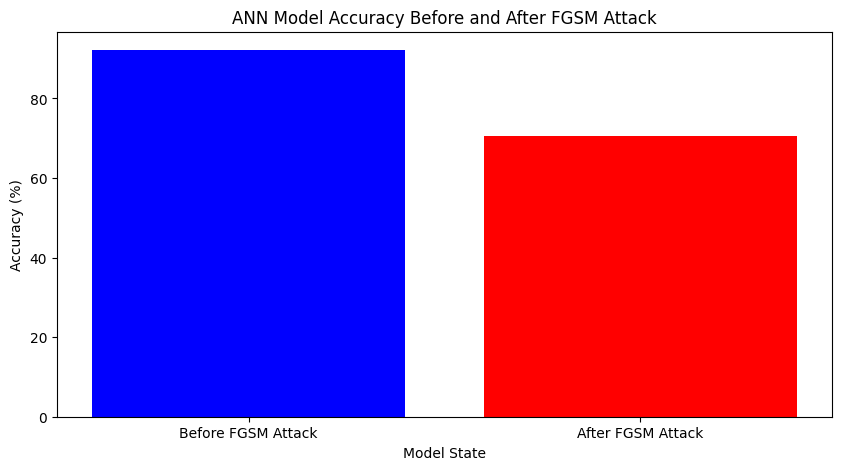

2/2 [==============================] - 0s 2ms/step


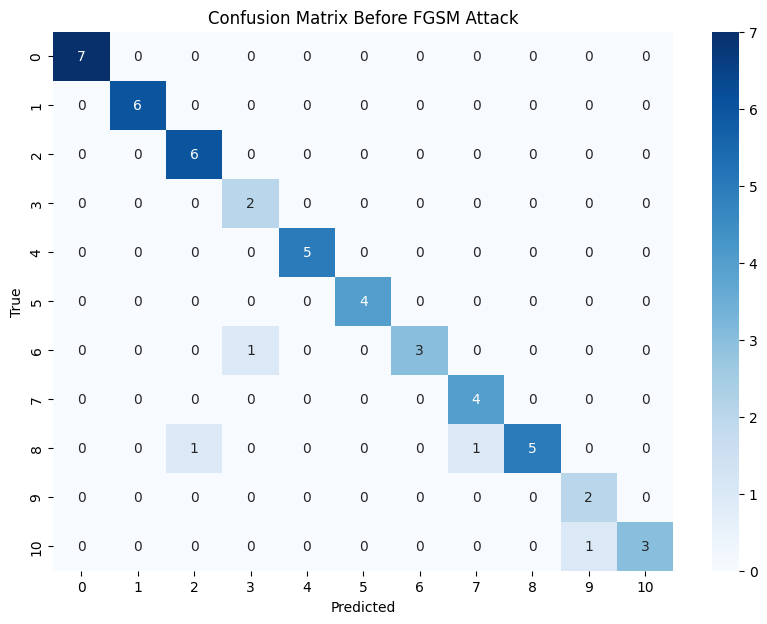

2/2 [==============================] - 0s 2ms/step


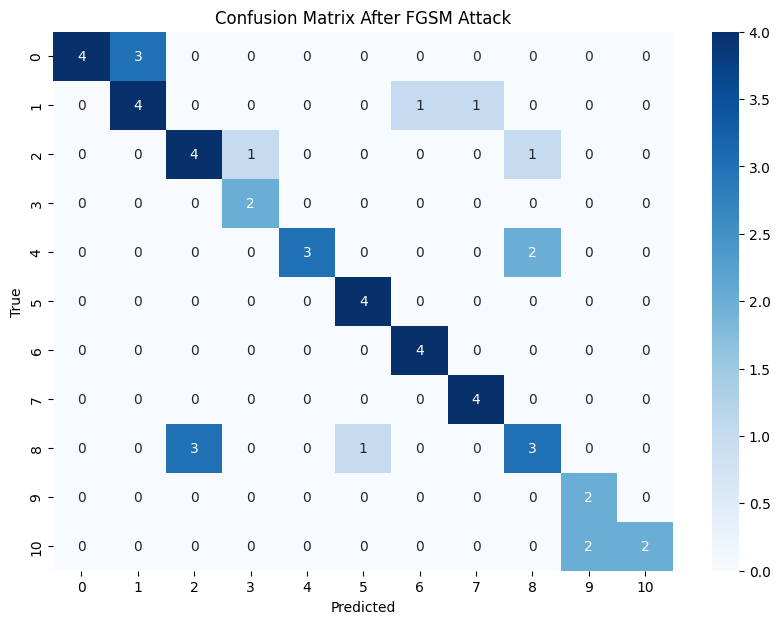

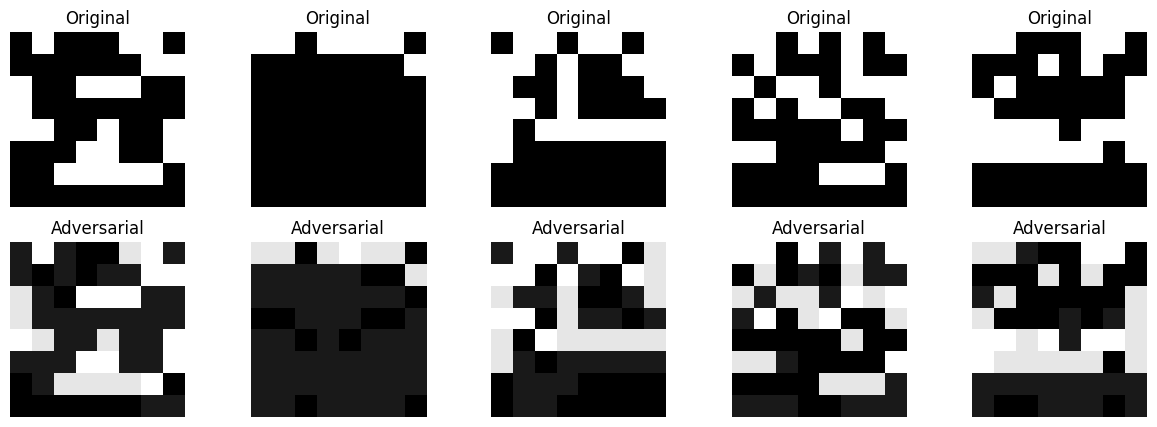

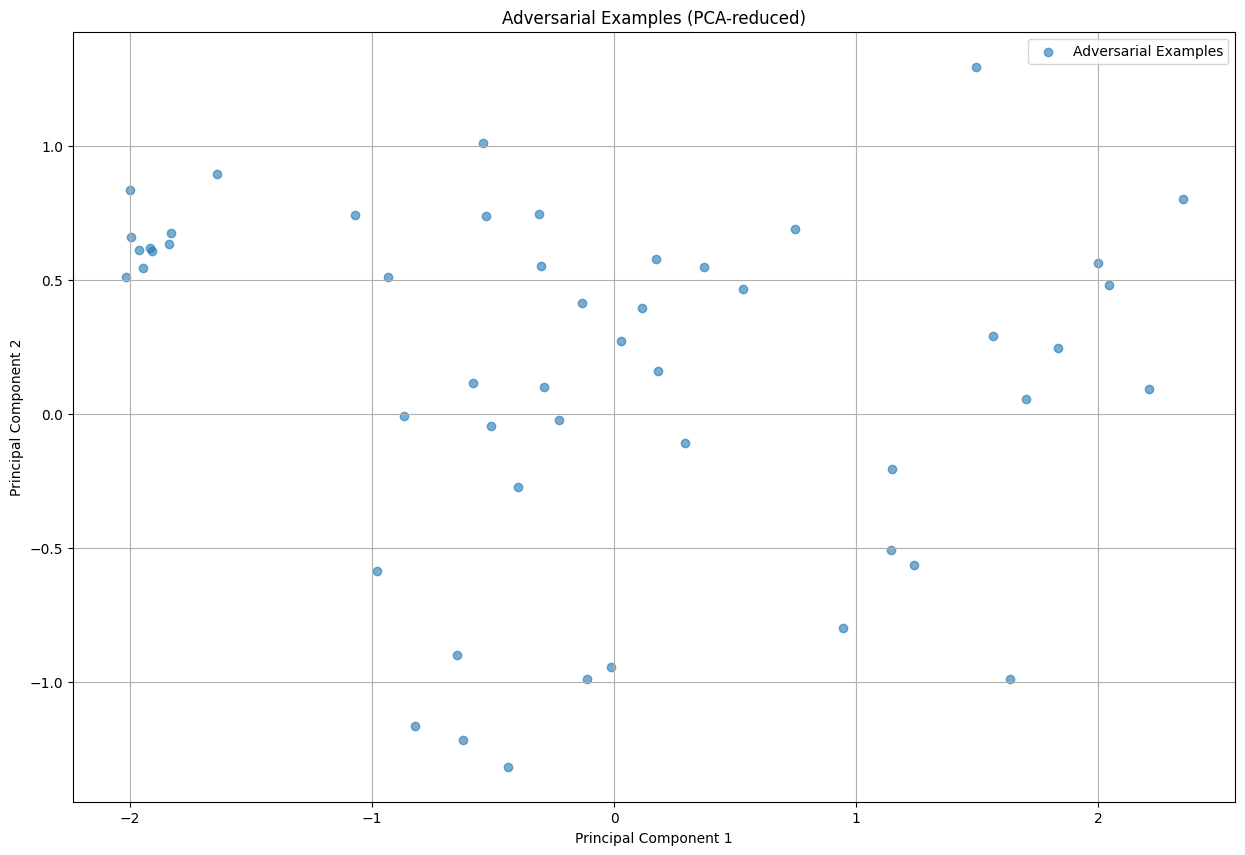

10512/10512 [==============================] - 10s 979us/step


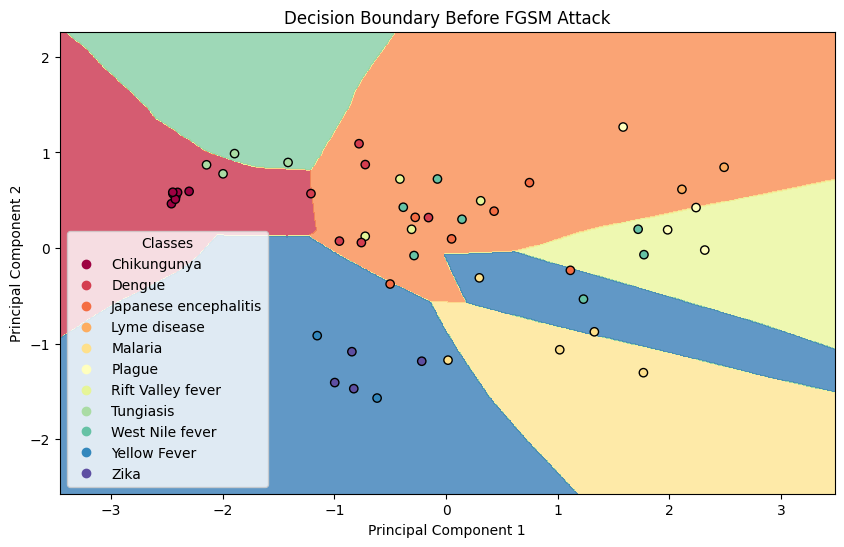

9197/9197 [==============================] - 9s 954us/step


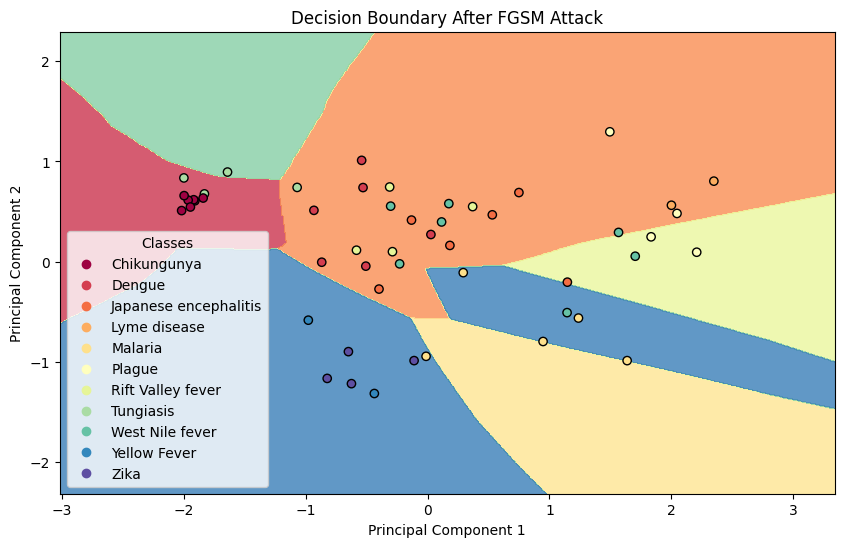

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize FGSM attack
attack = FastGradientMethod(estimator=classifier, eps=0.1)

# Perform FGSM attack on the test set
X_test_adv = attack.generate(X_test)

# Evaluate the model on the adversarial test set after attack
loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

# Plot model accuracy before and after FGSM attack
accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
labels = ['Before FGSM Attack', 'After FGSM Attack']

plt.figure(figsize=(10, 5))
plt.bar(labels, accuracies, color=['blue', 'red'])
plt.xlabel('Model State')
plt.ylabel('Accuracy (%)')
plt.title('ANN Model Accuracy Before and After FGSM Attack')
plt.show()

# Confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before FGSM Attack')
plt.show()

# Confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After FGSM Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
X_test_adv_pca = pca.transform(X_test_adv)

# Plot the adversarial examples
plt.figure(figsize=(15, 10))
plt.scatter(X_test_adv_pca[:, 0], X_test_adv_pca[:, 1], label='Adversarial Examples', alpha=0.6, cmap=plt.cm.Spectral)
plt.title('Adversarial Examples (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Plot decision boundaries before and after FGSM attack
def plot_decision_boundary(X, y, model, title, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before FGSM Attack', class_labels)
plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After FGSM Attack', class_labels)


2024-07-31 10:26:20.946986: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-31 10:26:21.105599: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-31 10:26:21.105627: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-07-31 10:26:21.125646: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-31 10:26:21.825803: W tensorflow/stream_executor/platform/de

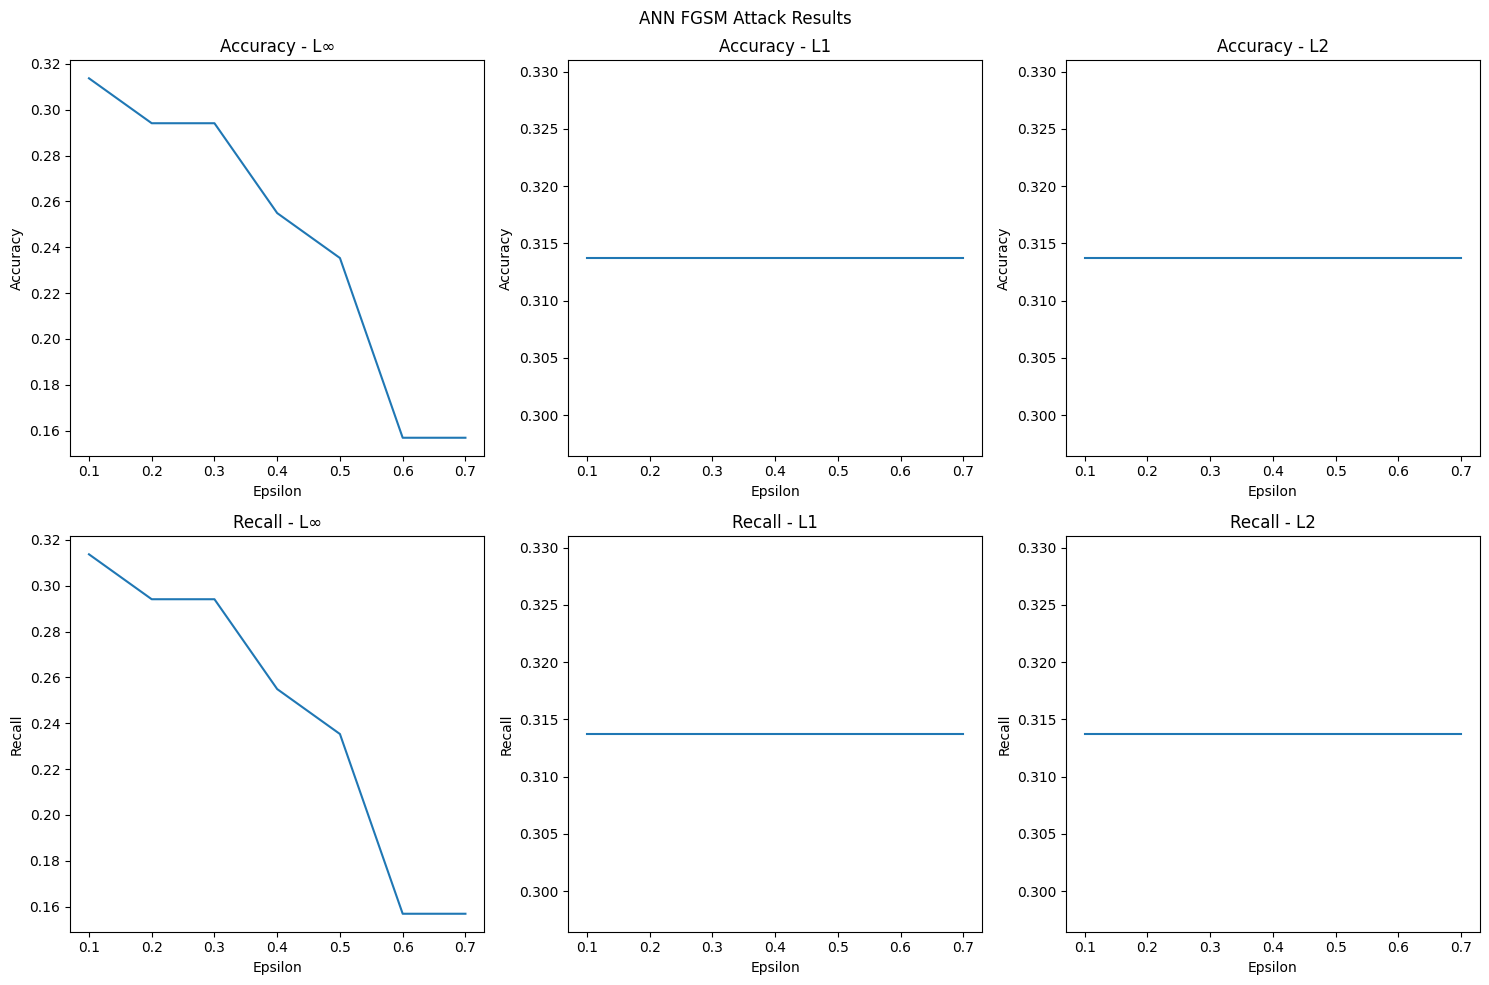


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.3137		0.3137
0.20	0.2941		0.2941
0.30	0.2941		0.2941
0.40	0.2549		0.2549
0.50	0.2353		0.2353
0.60	0.1569		0.1569
0.70	0.1569		0.1569

Results for L1 norm:
Epsilon	Accuracy	Recall
0.10	0.3137		0.3137
0.20	0.3137		0.3137
0.30	0.3137		0.3137
0.40	0.3137		0.3137
0.50	0.3137		0.3137
0.60	0.3137		0.3137
0.70	0.3137		0.3137

Results for L2 norm:
Epsilon	Accuracy	Recall
0.10	0.3137		0.3137
0.20	0.3137		0.3137
0.30	0.3137		0.3137
0.40	0.3137		0.3137
0.50	0.3137		0.3137
0.60	0.3137		0.3137
0.70	0.3137		0.3137
2/2 [==============================] - 0s 2ms/step


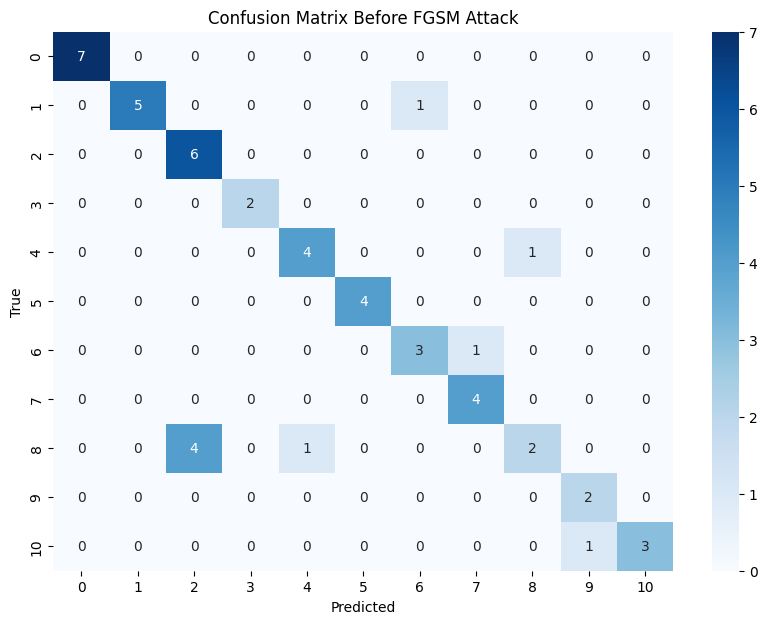

2/2 [==============================] - 0s 2ms/step


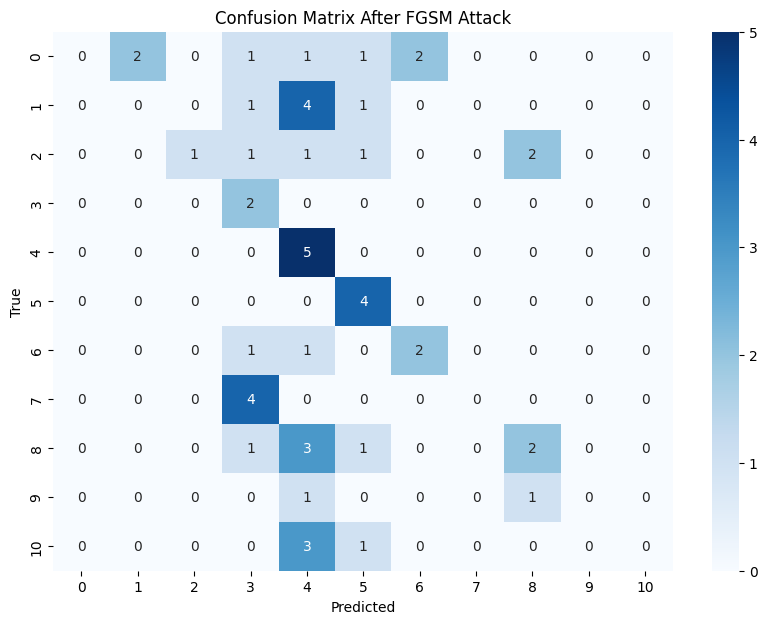

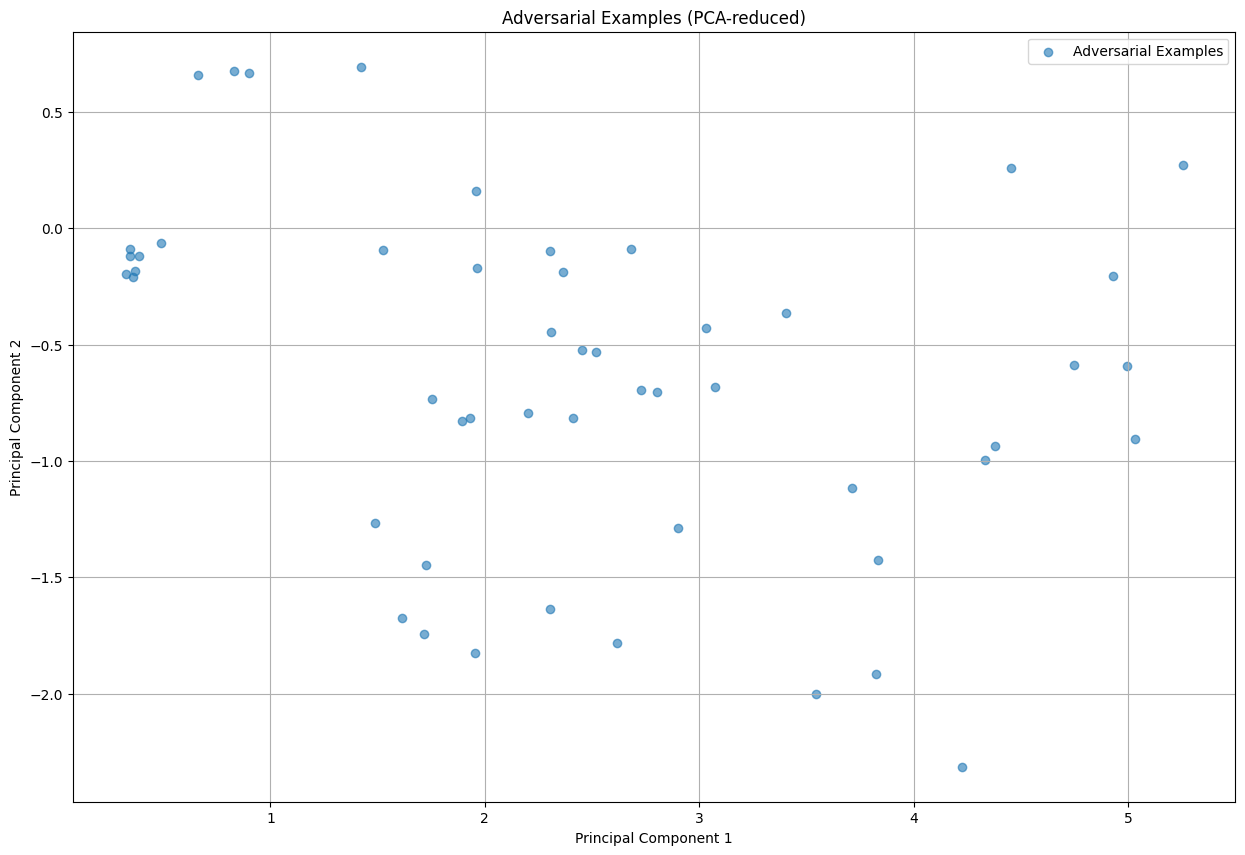

34438/34438 [==============================] - 32s 938us/step


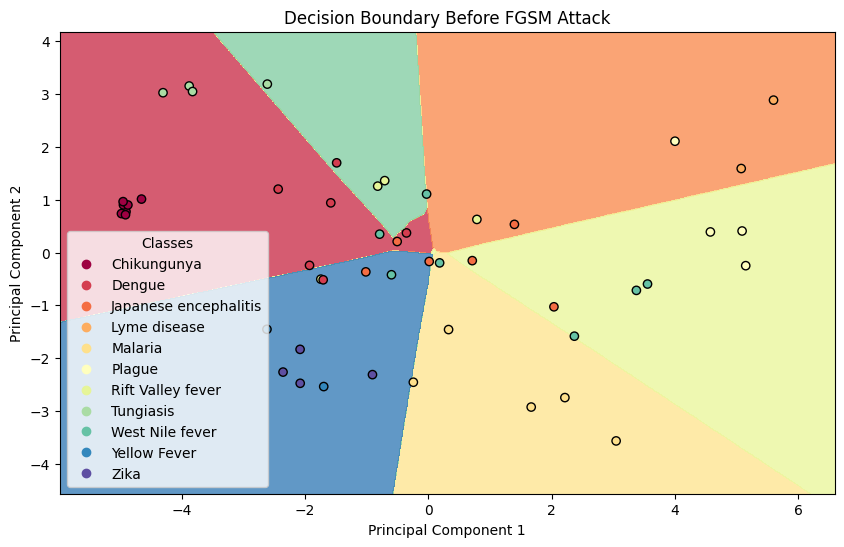

10866/10866 [==============================] - 10s 922us/step


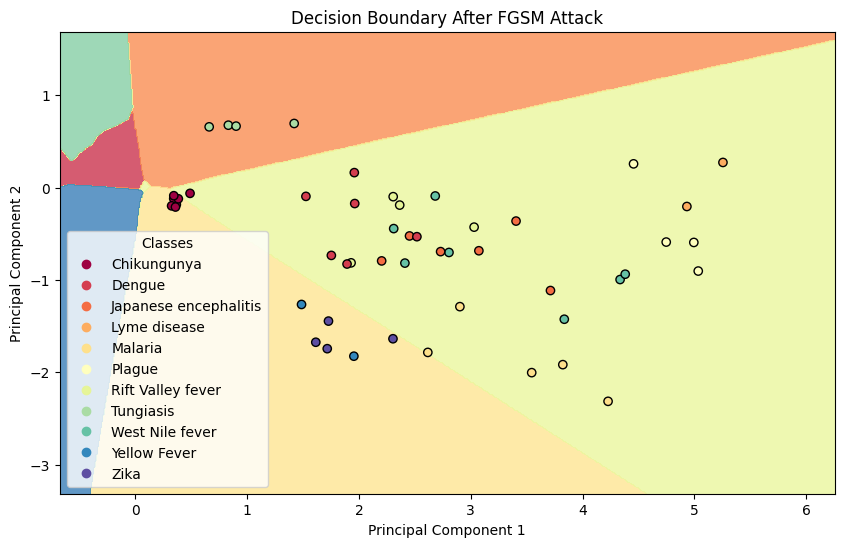

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train_scaled.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# FGSM attack function
@tf.function
def fgsm_attack(model, x, y, epsilon, norm):
    loss_object = tf.keras.losses.CategoricalCrossentropy()
    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x)
        loss = loss_object(y, prediction)
    gradient = tape.gradient(loss, x)
    
    if norm == np.inf:
        perturbation = epsilon * tf.sign(gradient)
    elif norm == 1:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=1, axis=1, keepdims=True))
    elif norm == 2:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=2, axis=1, keepdims=True))
    
    return tf.clip_by_value(x + perturbation, 0, 1)

# Perform attacks and evaluate
norms = [np.inf, 1, 2]
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = fgsm_attack(model, X_test_scaled, y_test, eps, norm)
        y_pred = np.argmax(model.predict(X_adv), axis=1)
        y_true = np.argmax(y_test, axis=1)
        accuracy = accuracy_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('ANN FGSM Attack Results')

for i, norm in enumerate(norms):
    axs[0, i].plot(eps_values, results[norm]['accuracy'])
    axs[0, i].set_title(f'Accuracy - L{norm if norm != np.inf else "∞"}')
    axs[0, i].set_xlabel('Epsilon')
    axs[0, i].set_ylabel('Accuracy')

    axs[1, i].plot(eps_values, results[norm]['recall'])
    axs[1, i].set_title(f'Recall - L{norm if norm != np.inf else "∞"}')
    axs[1, i].set_xlabel('Epsilon')
    axs[1, i].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
for norm in norms:
    print(f"\nResults for L{norm if norm != np.inf else '∞'} norm:")
    print("Epsilon\tAccuracy\tRecall")
    for eps, acc, rec in zip(eps_values, results[norm]['accuracy'], results[norm]['recall']):
        print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")

# Confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test_scaled), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before FGSM Attack')
plt.show()

# Confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After FGSM Attack')
plt.show()

# Apply PCA for visualization
X_test_adv_pca = pca.transform(X_adv)

# Plot the adversarial examples
plt.figure(figsize=(15, 10))
plt.scatter(X_test_adv_pca[:, 0], X_test_adv_pca[:, 1], label='Adversarial Examples', alpha=0.6, cmap=plt.cm.Spectral)
plt.title('Adversarial Examples (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Plot decision boundaries before and after FGSM attack
def plot_decision_boundary(X, y, model, title, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before FGSM Attack', class_labels)
plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After FGSM Attack', class_labels)


Accuracy before attack: 84.31%
2/2 [==============================] - 0s 2ms/step


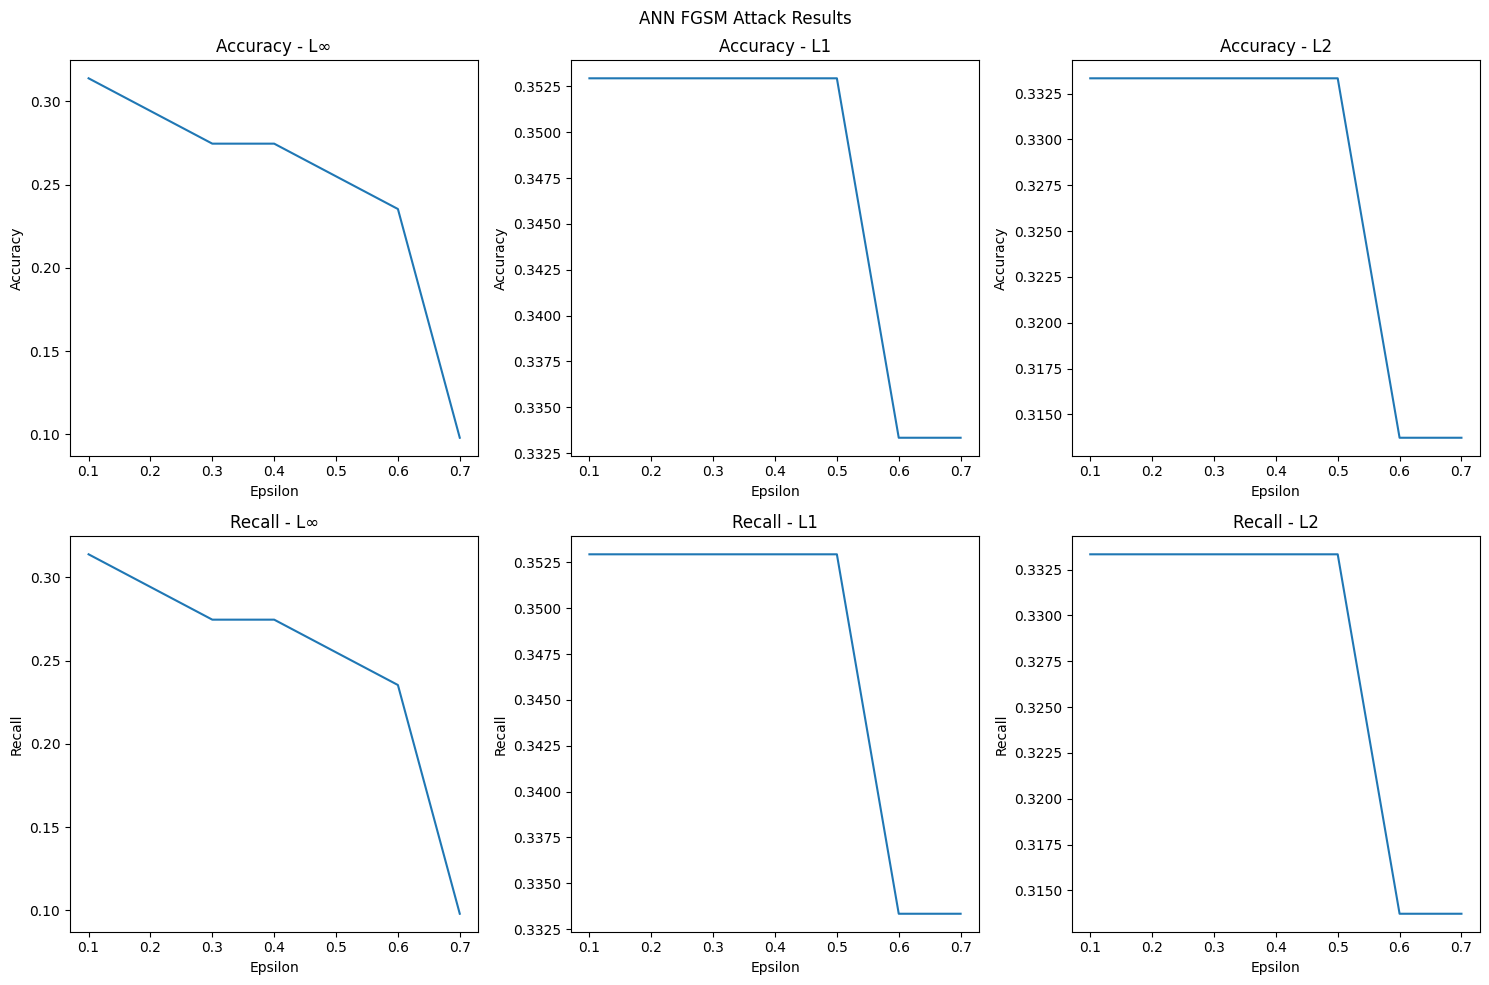


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.3137		0.3137
0.20	0.2941		0.2941
0.30	0.2745		0.2745
0.40	0.2745		0.2745
0.50	0.2549		0.2549
0.60	0.2353		0.2353
0.70	0.0980		0.0980

Results for L1 norm:
Epsilon	Accuracy	Recall
0.10	0.3529		0.3529
0.20	0.3529		0.3529
0.30	0.3529		0.3529
0.40	0.3529		0.3529
0.50	0.3529		0.3529
0.60	0.3333		0.3333
0.70	0.3333		0.3333

Results for L2 norm:
Epsilon	Accuracy	Recall
0.10	0.3333		0.3333
0.20	0.3333		0.3333
0.30	0.3333		0.3333
0.40	0.3333		0.3333
0.50	0.3333		0.3333
0.60	0.3137		0.3137
0.70	0.3137		0.3137


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train_scaled.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# FGSM attack function
@tf.function
def fgsm_attack(model, x, y, epsilon, norm):
    loss_object = tf.keras.losses.CategoricalCrossentropy()
    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x)
        loss = loss_object(y, prediction)
    gradient = tape.gradient(loss, x)
    
    if norm == np.inf:
        perturbation = epsilon * tf.sign(gradient)
    elif norm == 1:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=1, axis=1, keepdims=True))
    elif norm == 2:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=2, axis=1, keepdims=True))
    
    return tf.clip_by_value(x + perturbation, 0, 1)

# Perform attacks and evaluate
norms = [np.inf, 1, 2]
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = fgsm_attack(model, X_test_scaled, y_test, eps, norm)
        y_pred = np.argmax(model.predict(X_adv), axis=1)
        y_true = np.argmax(y_test, axis=1)
        accuracy = accuracy_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('ANN FGSM Attack Results')

for i, norm in enumerate(norms):
    axs[0, i].plot(eps_values, results[norm]['accuracy'])
    axs[0, i].set_title(f'Accuracy - L{norm if norm != np.inf else "∞"}')
    axs[0, i].set_xlabel('Epsilon')
    axs[0, i].set_ylabel('Accuracy')

    axs[1, i].plot(eps_values, results[norm]['recall'])
    axs[1, i].set_title(f'Recall - L{norm if norm != np.inf else "∞"}')
    axs[1, i].set_xlabel('Epsilon')
    axs[1, i].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
for norm in norms:
    print(f"\nResults for L{norm if norm != np.inf else '∞'} norm:")
    print("Epsilon\tAccuracy\tRecall")
    for eps, acc, rec in zip(eps_values, results[norm]['accuracy'], results[norm]['recall']):
        print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")



# FGSM Attack with XGBoost:

Accuracy before attack: 88.24%
Accuracy after attack: 50.98%


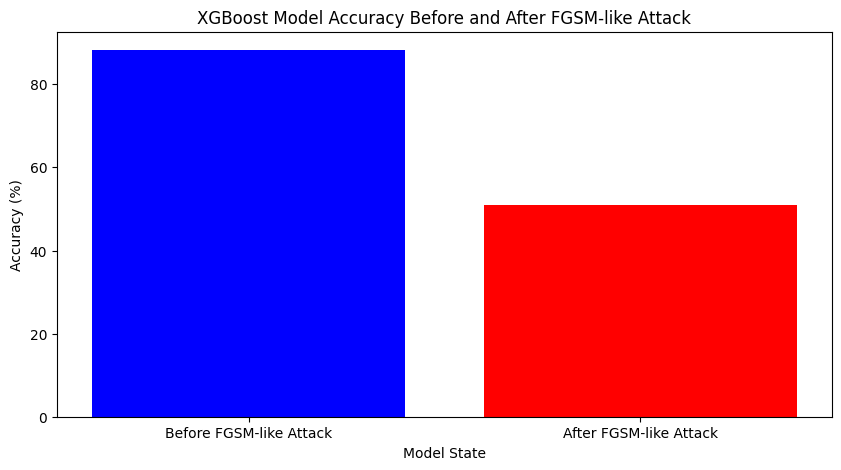

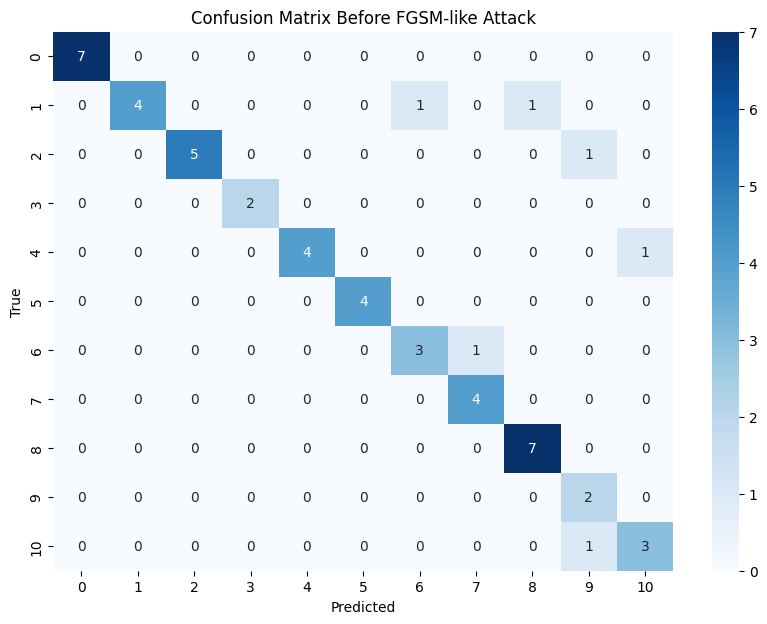

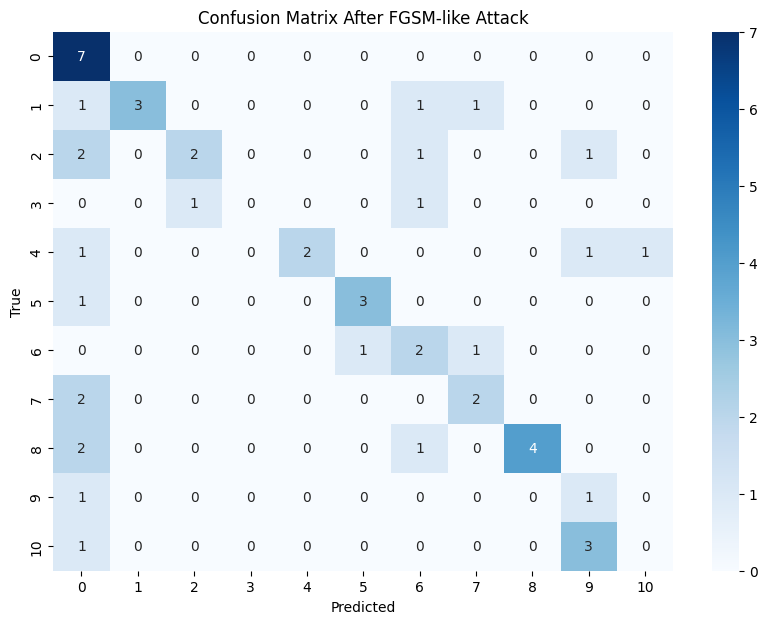

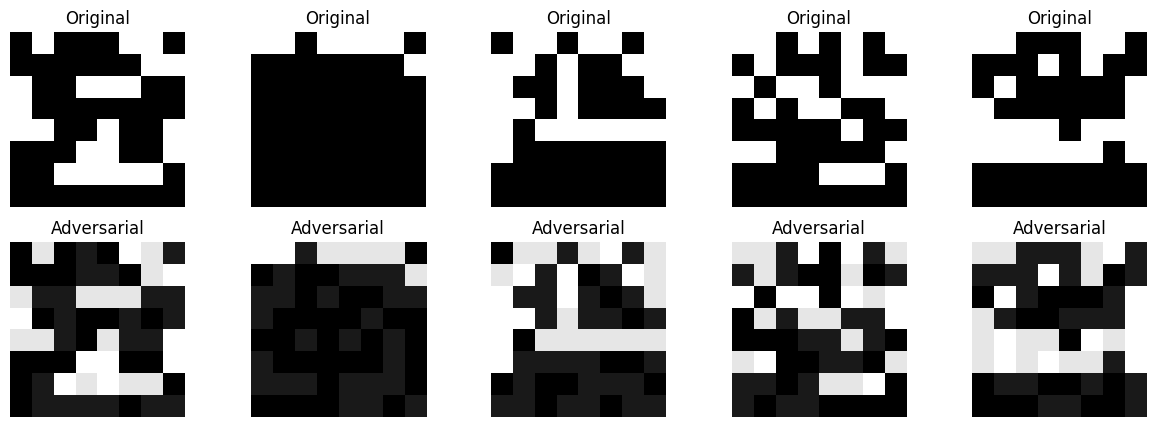

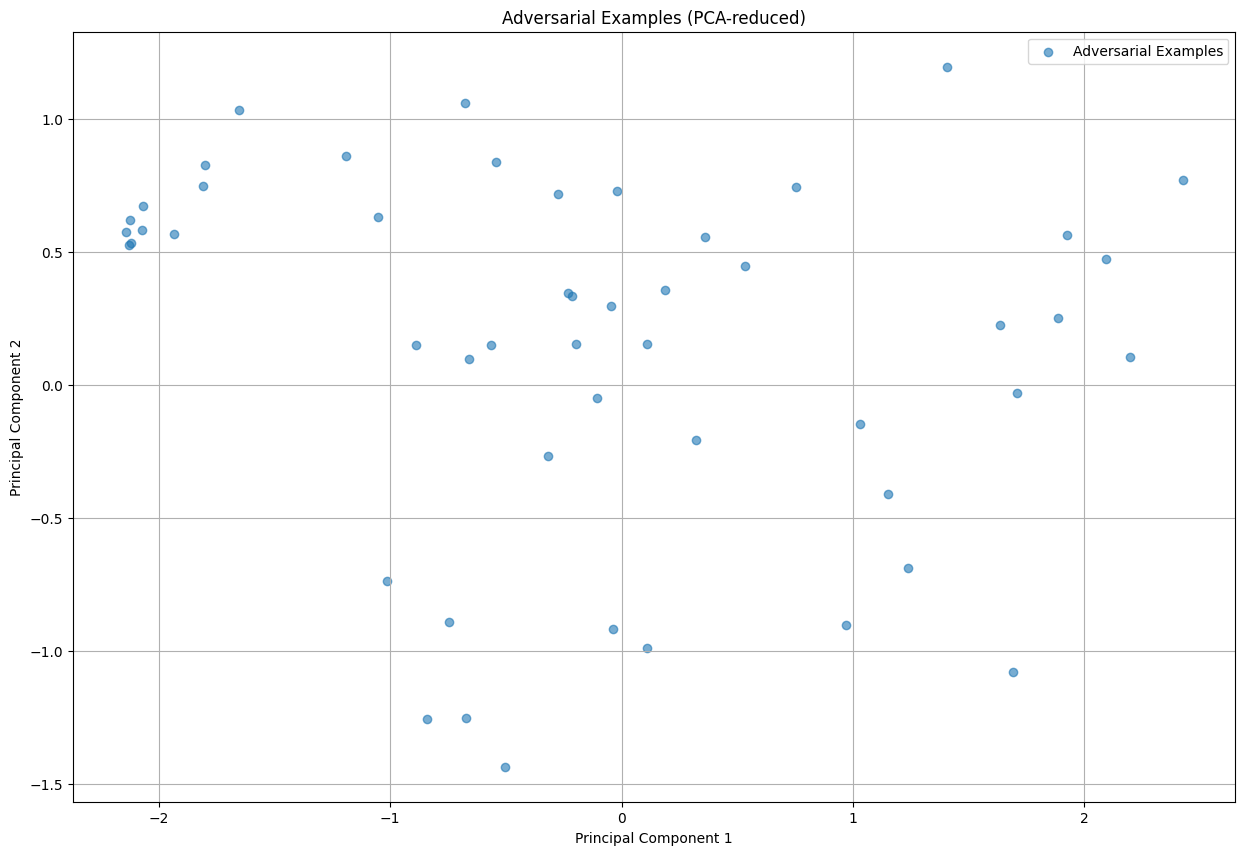

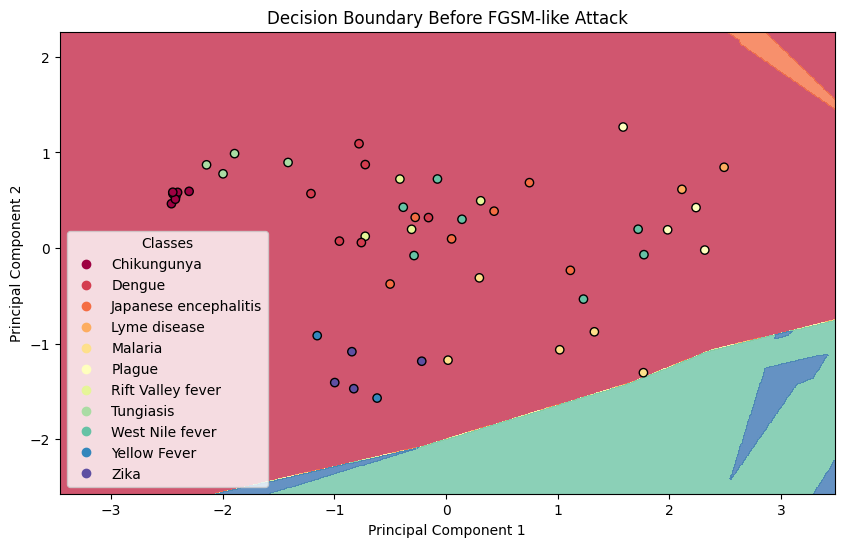

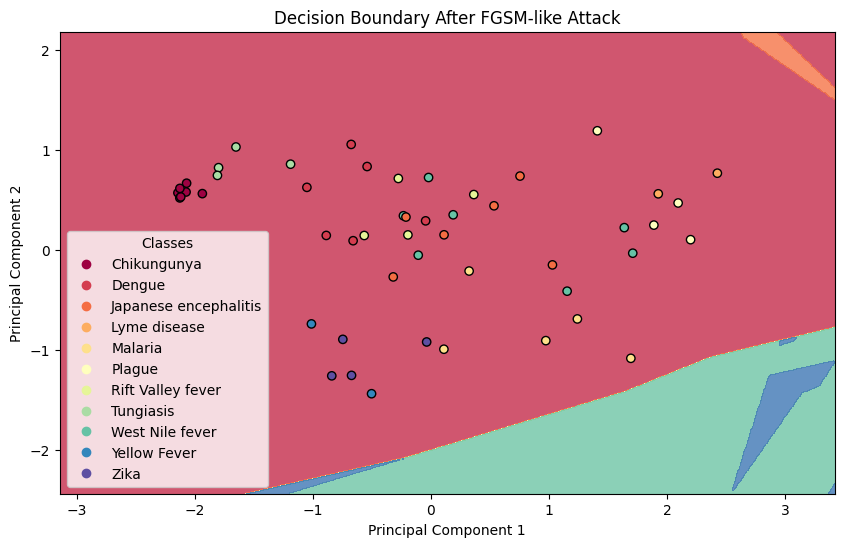

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define and train the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Initial predictions and accuracy
y_pred = xgb_model.predict(X_test)
accuracy_before_attack = accuracy_score(y_test, y_pred)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Initialize FGSM-like perturbation
eps = 0.1  # Perturbation magnitude

# Apply FGSM-like perturbation
perturbation = eps * np.sign(np.random.randn(*X_test.shape))
X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

# Evaluate the model on the adversarial test set after attack
y_pred_adv = xgb_model.predict(X_test_adv)
accuracy_after_attack = accuracy_score(y_test, y_pred_adv)
print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

# Plot model accuracy before and after FGSM-like attack
accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

plt.figure(figsize=(10, 5))
plt.bar(labels, accuracies, color=['blue', 'red'])
plt.xlabel('Model State')
plt.ylabel('Accuracy (%)')
plt.title('XGBoost Model Accuracy Before and After FGSM-like Attack')
plt.show()

# Confusion matrix before attack
cm_before = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before FGSM-like Attack')
plt.show()

# Confusion matrix after attack
cm_after = confusion_matrix(y_test, y_pred_adv)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After FGSM-like Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
X_test_adv_pca = pca.transform(X_test_adv)

# Plot the adversarial examples
plt.figure(figsize=(15, 10))
plt.scatter(X_test_adv_pca[:, 0], X_test_adv_pca[:, 1], label='Adversarial Examples', alpha=0.6, cmap=plt.cm.Spectral)
plt.title('Adversarial Examples (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Plot decision boundaries before and after FGSM-like attack
def plot_decision_boundary(X, y, model, title, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, xgb_model, 'Decision Boundary Before FGSM-like Attack', class_labels)
plot_decision_boundary(X_test_adv_pca, y_test, xgb_model, 'Decision Boundary After FGSM-like Attack', class_labels)


# FGSM Attack with CNN:

Epoch 1/10
21/21 [==============================] - 0s 1ms/step - loss: 2.3183 - accuracy: 0.1741
Epoch 2/10
21/21 [==============================] - 0s 2ms/step - loss: 2.0511 - accuracy: 0.3085
Epoch 3/10
21/21 [==============================] - 0s 4ms/step - loss: 1.7149 - accuracy: 0.5970
Epoch 4/10
21/21 [==============================] - 0s 1ms/step - loss: 1.3102 - accuracy: 0.7761
Epoch 5/10
21/21 [==============================] - 0s 4ms/step - loss: 0.9766 - accuracy: 0.8358
Epoch 6/10
21/21 [==============================] - 0s 4ms/step - loss: 0.7497 - accuracy: 0.8408
Epoch 7/10
21/21 [==============================] - 0s 1ms/step - loss: 0.6292 - accuracy: 0.8557
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.5222 - accuracy: 0.8557
Epoch 9/10
21/21 [==============================] - 0s 1ms/step - loss: 0.4824 - accuracy: 0.8806
Epoch 10/10
21/21 [==============================] - 0s 4ms/step - loss: 0.3853 - accuracy: 0.9353
Accuracy before att

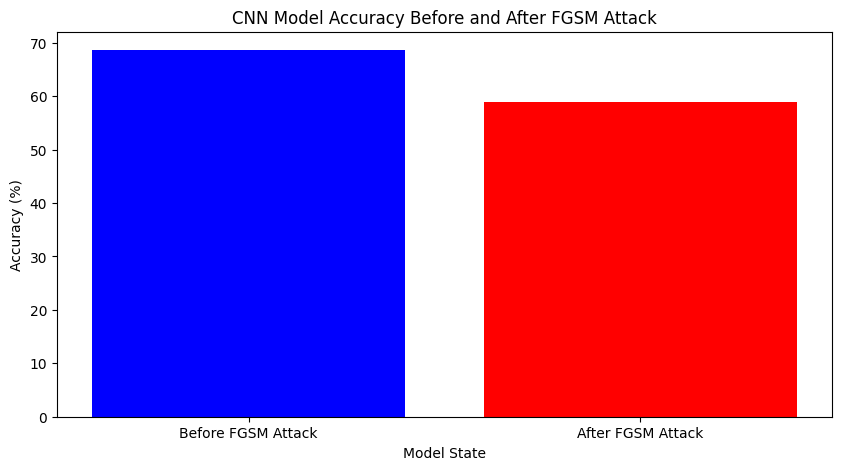

2/2 [==============================] - 0s 2ms/step


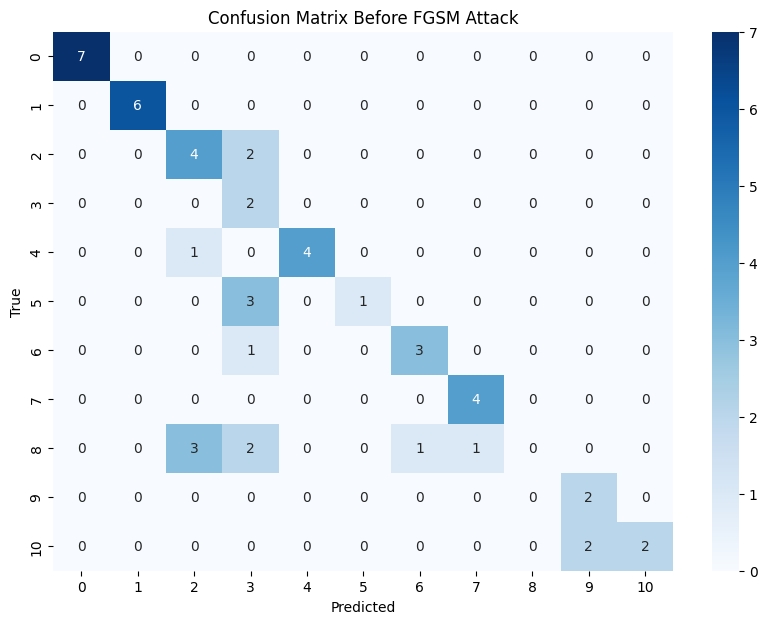

2/2 [==============================] - 0s 2ms/step


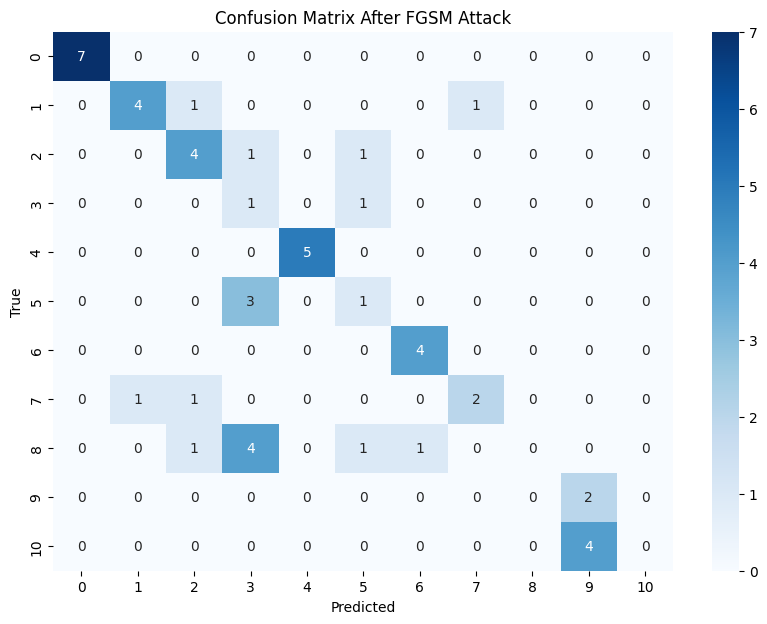

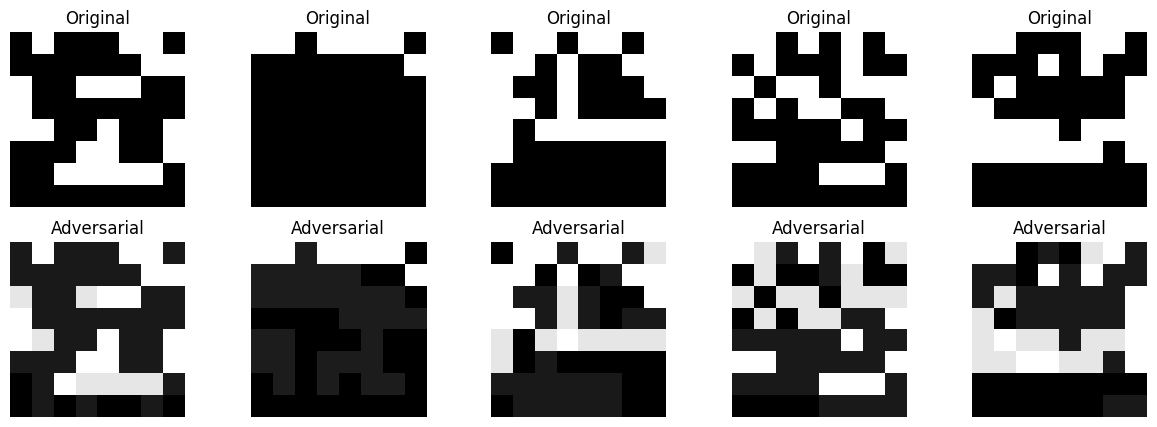

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Reshape the data for CNN input
X = X.reshape(X.shape[0], 8, 8, 1)  # Adjust the shape according to your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Define the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the CNN model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the CNN model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(8, 8, 1),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize FGSM attack
attack = FastGradientMethod(estimator=classifier, eps=0.1)

# Perform FGSM attack on the test set
X_test_adv = attack.generate(X_test)

# Evaluate the model on the adversarial test set after attack
loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

# Plot model accuracy before and after FGSM attack
accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
labels = ['Before FGSM Attack', 'After FGSM Attack']

plt.figure(figsize=(10, 5))
plt.bar(labels, accuracies, color=['blue', 'red'])
plt.xlabel('Model State')
plt.ylabel('Accuracy (%)')
plt.title('CNN Model Accuracy Before and After FGSM Attack')
plt.show()

# Confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before FGSM Attack')
plt.show()

# Confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After FGSM Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Since PCA is not typically applied to image data directly for decision boundary visualization,
# we'll skip PCA-related steps for CNN. If needed, PCA can be applied to the flattened image data.

# For CNN, we can visualize the original and adversarial examples directly.


#  FGSM-like Attack with SVM:

Accuracy before attack: 80.39%
Accuracy after attack: 82.35%


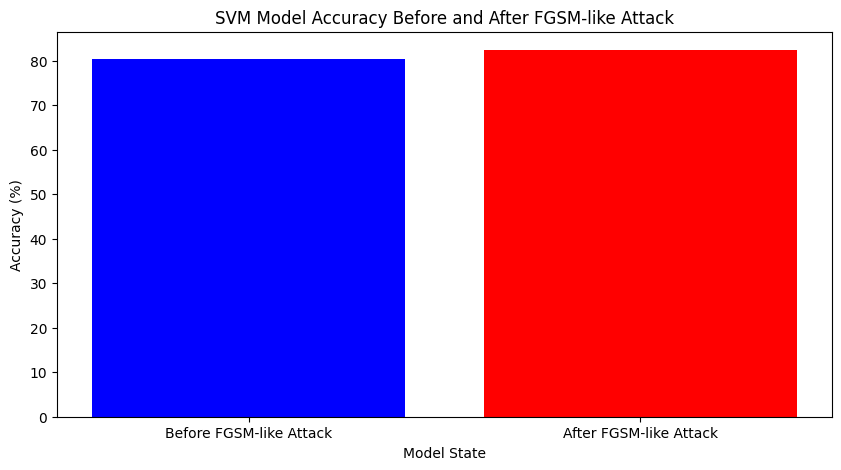

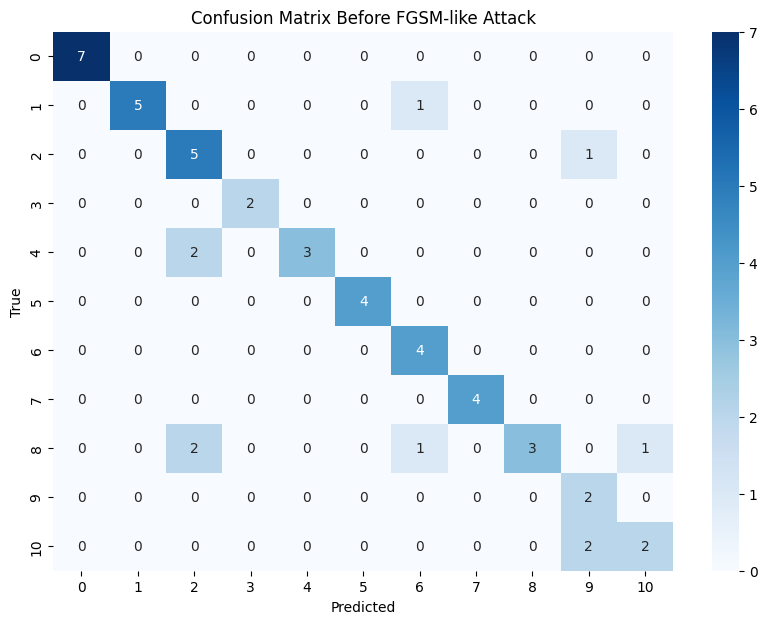

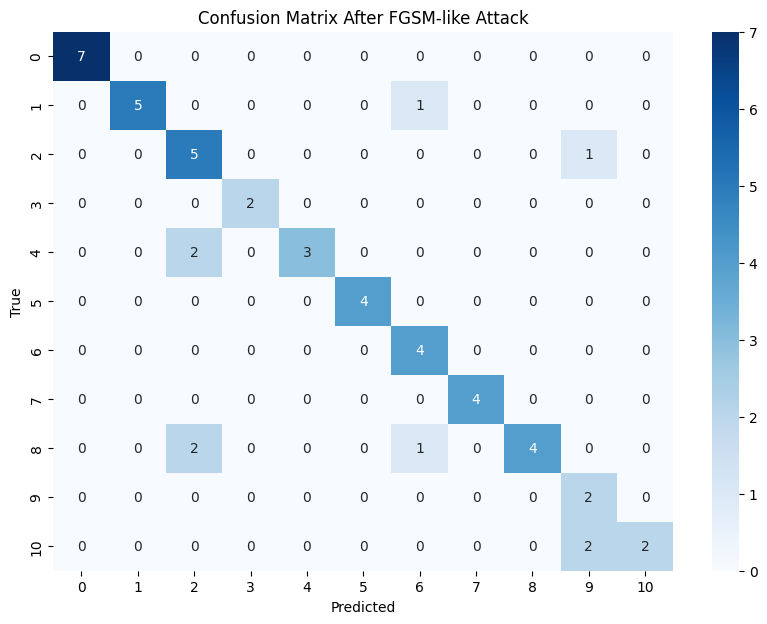

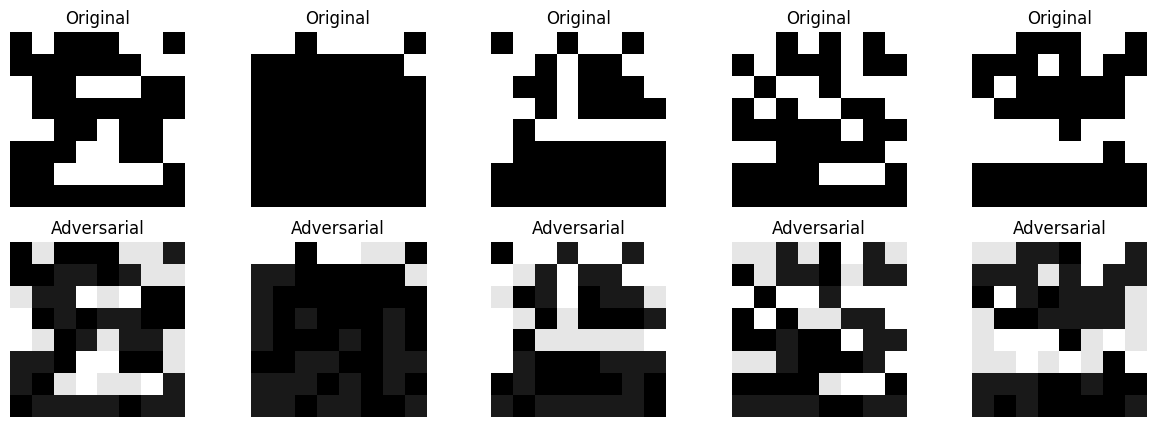

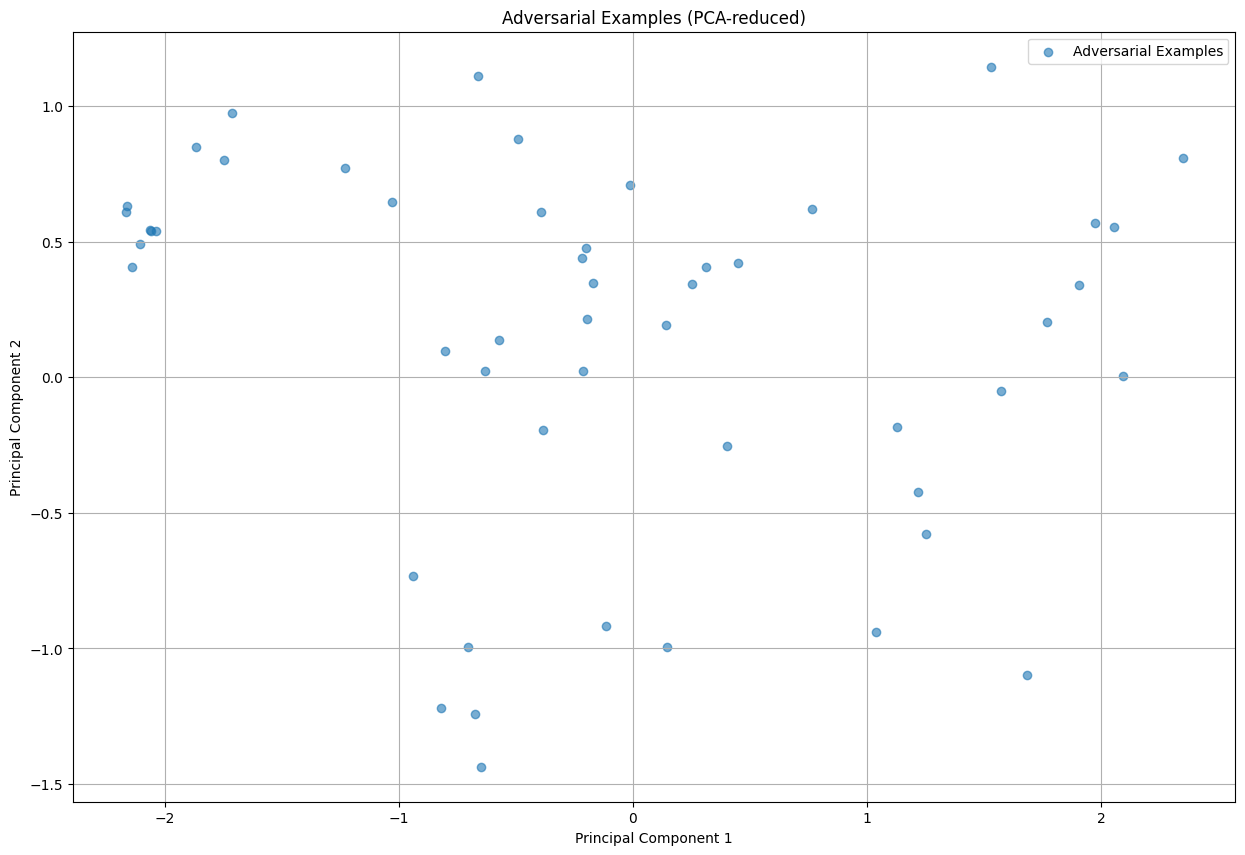

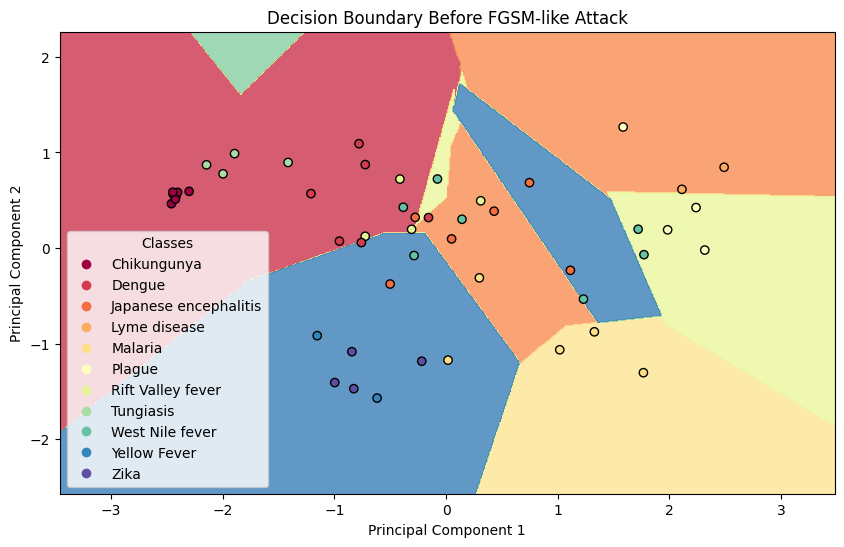

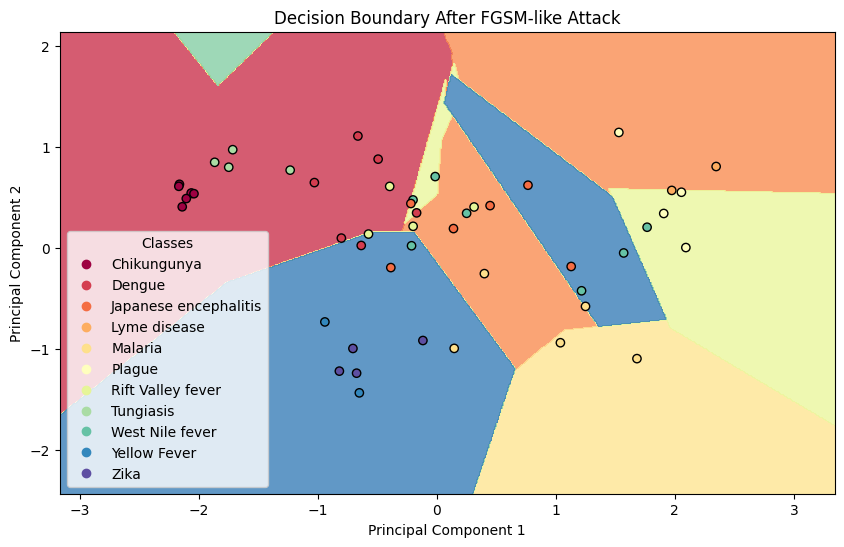

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define and train the SVM model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Initial predictions and accuracy
y_pred = svm_model.predict(X_test)
accuracy_before_attack = accuracy_score(y_test, y_pred)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Initialize FGSM-like perturbation
eps = 0.1  # Perturbation magnitude

# Apply FGSM-like perturbation
perturbation = eps * np.sign(np.random.randn(*X_test.shape))
X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

# Evaluate the model on the adversarial test set after attack
y_pred_adv = svm_model.predict(X_test_adv)
accuracy_after_attack = accuracy_score(y_test, y_pred_adv)
print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

# Plot model accuracy before and after FGSM-like attack
accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

plt.figure(figsize=(10, 5))
plt.bar(labels, accuracies, color=['blue', 'red'])
plt.xlabel('Model State')
plt.ylabel('Accuracy (%)')
plt.title('SVM Model Accuracy Before and After FGSM-like Attack')
plt.show()

# Confusion matrix before attack
cm_before = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before FGSM-like Attack')
plt.show()

# Confusion matrix after attack
cm_after = confusion_matrix(y_test, y_pred_adv)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After FGSM-like Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
X_test_adv_pca = pca.transform(X_test_adv)

# Plot the adversarial examples
plt.figure(figsize=(15, 10))
plt.scatter(X_test_adv_pca[:, 0], X_test_adv_pca[:, 1], label='Adversarial Examples', alpha=0.6, cmap=plt.cm.Spectral)
plt.title('Adversarial Examples (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Plot decision boundaries before and after FGSM-like attack
def plot_decision_boundary(X, y, model, title, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, svm_model, 'Decision Boundary Before FGSM-like Attack', class_labels)
plot_decision_boundary(X_test_adv_pca, y_test, svm_model, 'Decision Boundary After FGSM-like Attack', class_labels)


Epoch 1/10
21/21 [==============================] - 0s 1ms/step - loss: 2.2986 - accuracy: 0.1343
Epoch 2/10
21/21 [==============================] - 0s 973us/step - loss: 1.9057 - accuracy: 0.4129
Epoch 3/10
21/21 [==============================] - 0s 1ms/step - loss: 1.5469 - accuracy: 0.6418
Epoch 4/10
21/21 [==============================] - 0s 4ms/step - loss: 1.1576 - accuracy: 0.8657
Epoch 5/10
21/21 [==============================] - 0s 1ms/step - loss: 0.8201 - accuracy: 0.9104
Epoch 6/10
21/21 [==============================] - 0s 4ms/step - loss: 0.5612 - accuracy: 0.9353
Epoch 7/10
21/21 [==============================] - 0s 958us/step - loss: 0.3914 - accuracy: 0.9701
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.2779 - accuracy: 0.9801
Epoch 9/10
21/21 [==============================] - 0s 997us/step - loss: 0.2128 - accuracy: 0.9851
Epoch 10/10
21/21 [==============================] - 0s 4ms/step - loss: 0.1555 - accuracy: 0.9900
Accuracy befo

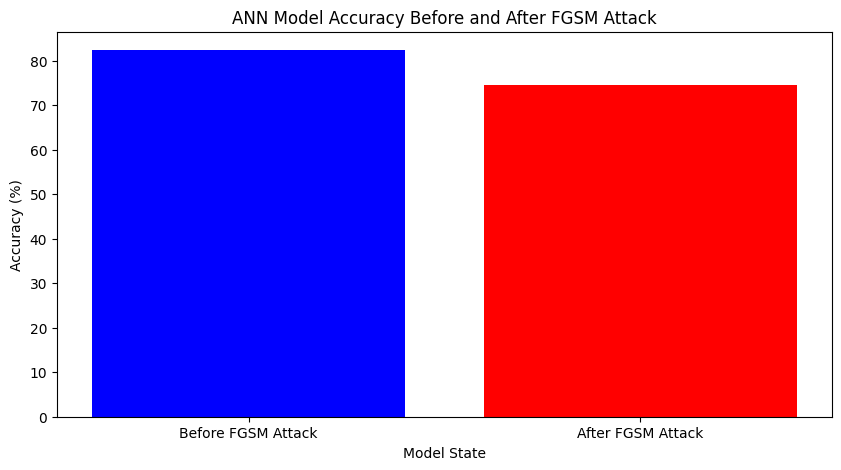

2/2 [==============================] - 0s 2ms/step


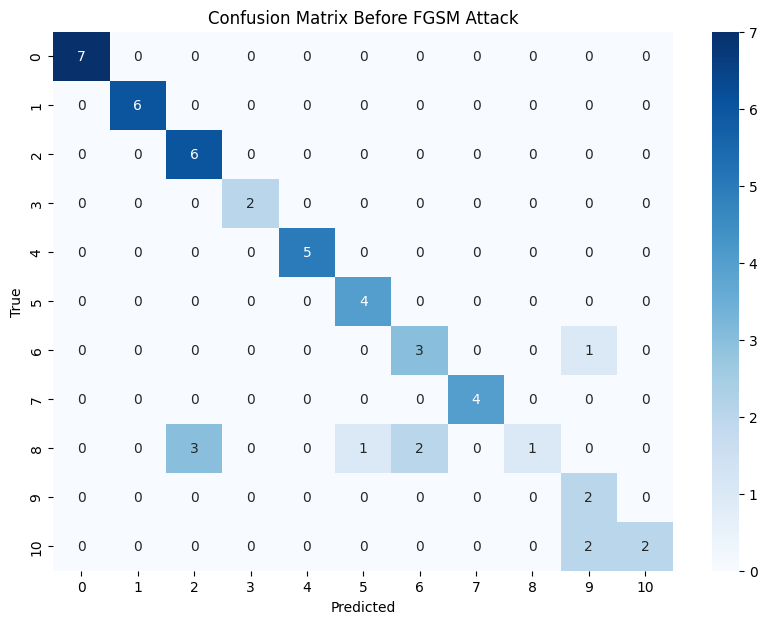

2/2 [==============================] - 0s 2ms/step


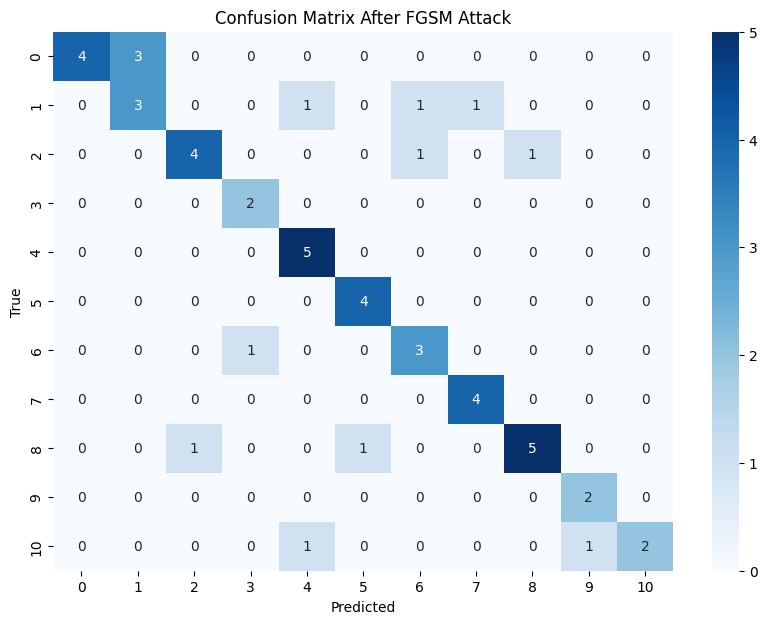

13723/13723 [==============================] - 13s 969us/step


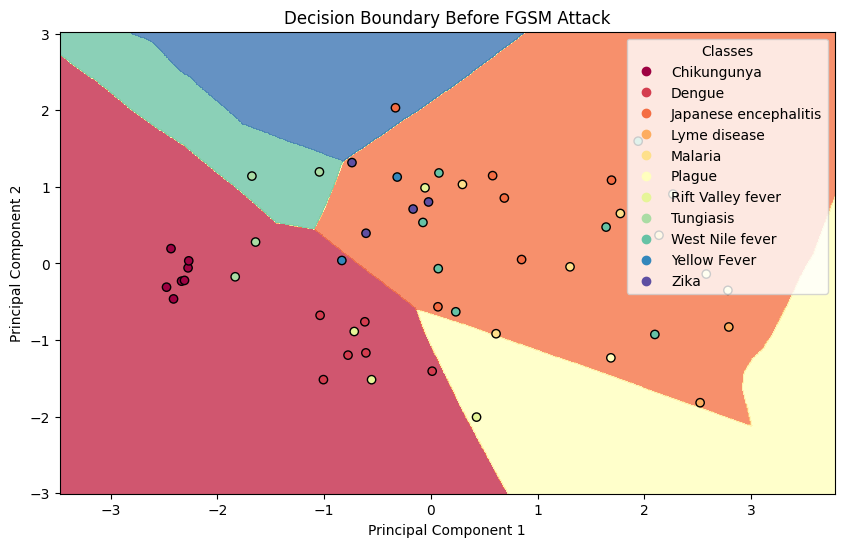

11571/11571 [==============================] - 11s 963us/step


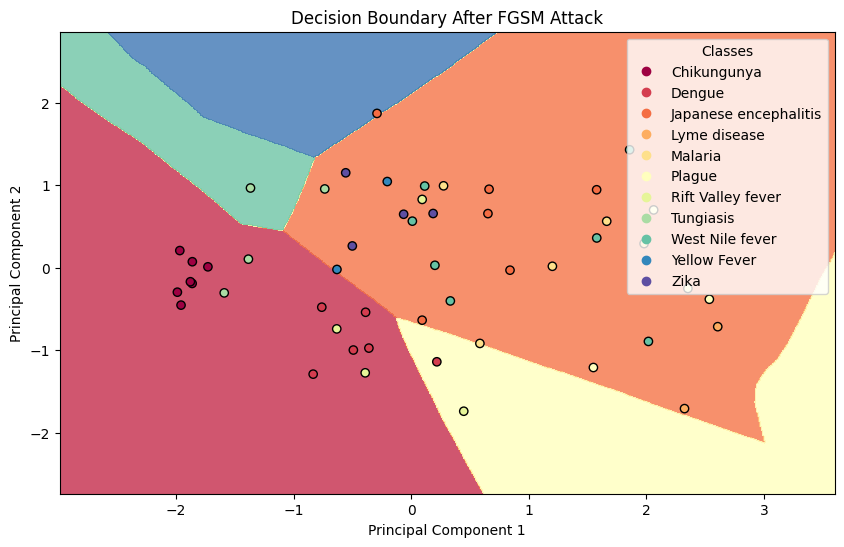

Epoch 1/10
21/21 [==============================] - 1s 2ms/step - loss: 2.3171 - accuracy: 0.2040 
Epoch 2/10
21/21 [==============================] - 0s 4ms/step - loss: 2.0483 - accuracy: 0.5224
Epoch 3/10
21/21 [==============================] - 0s 1ms/step - loss: 1.7035 - accuracy: 0.6418
Epoch 4/10
21/21 [==============================] - 0s 1ms/step - loss: 1.3201 - accuracy: 0.7114
Epoch 5/10
21/21 [==============================] - 0s 4ms/step - loss: 1.0168 - accuracy: 0.7164
Epoch 6/10
21/21 [==============================] - 0s 2ms/step - loss: 0.8050 - accuracy: 0.8209
Epoch 7/10
21/21 [==============================] - 0s 1ms/step - loss: 0.6415 - accuracy: 0.8408
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.5215 - accuracy: 0.8756
Epoch 9/10
21/21 [==============================] - 0s 1ms/step - loss: 0.4207 - accuracy: 0.9353
Epoch 10/10
21/21 [==============================] - 0s 4ms/step - loss: 0.3990 - accuracy: 0.8657
Accuracy before at

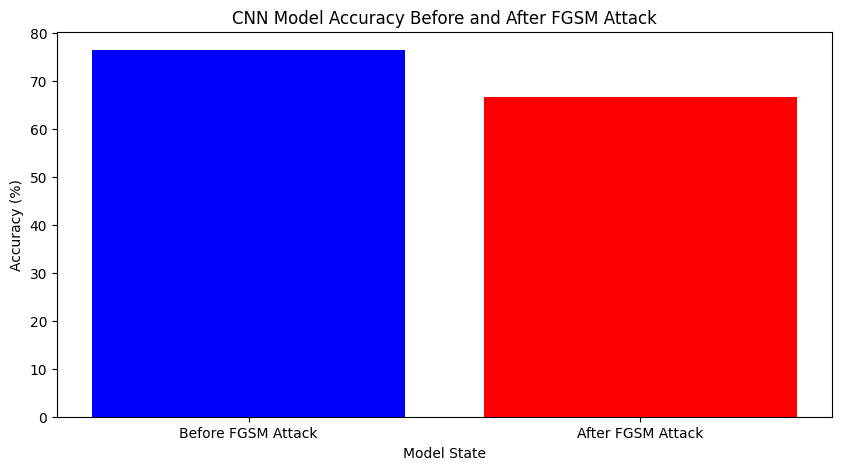

2/2 [==============================] - 0s 2ms/step


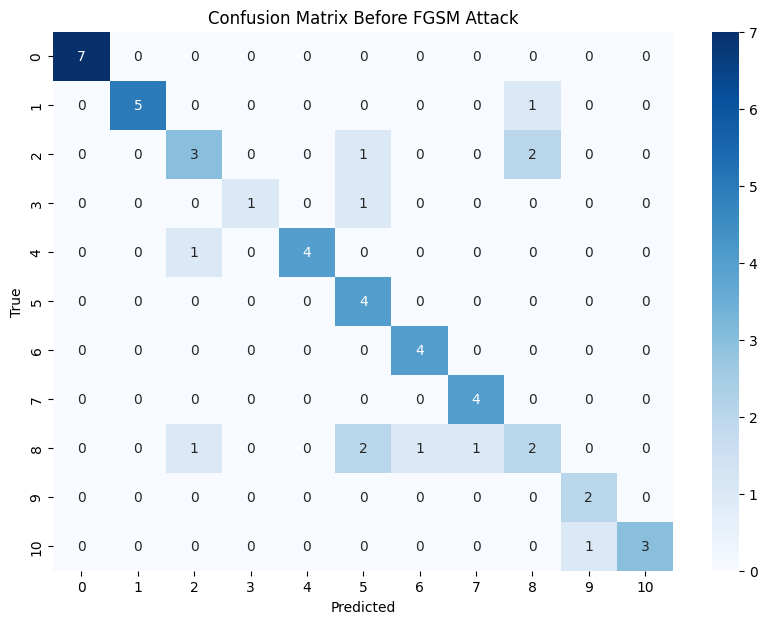

2/2 [==============================] - 0s 2ms/step


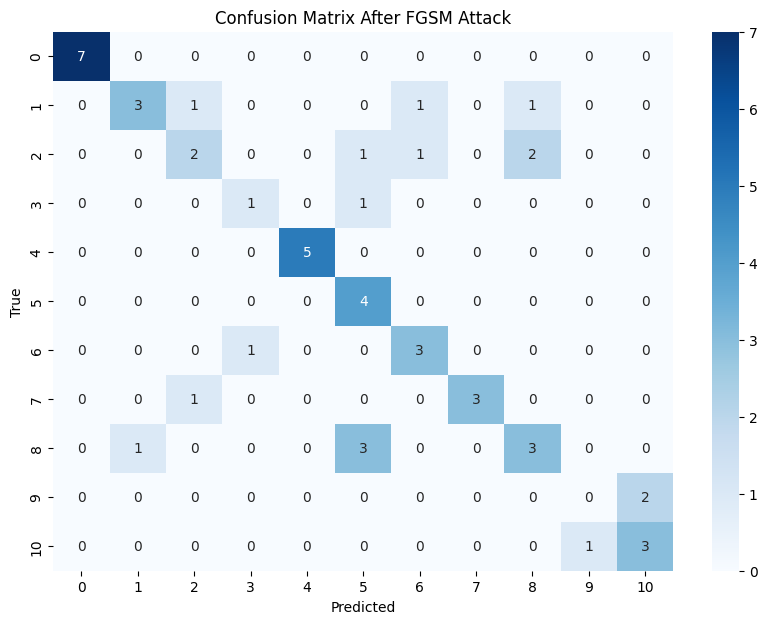

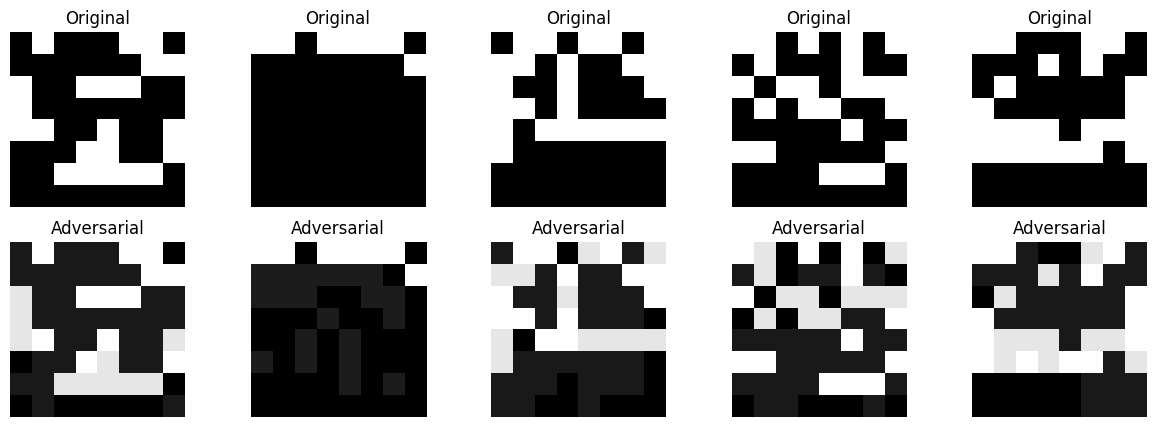

Accuracy before attack: 66.67%
Accuracy after attack: 15.69%


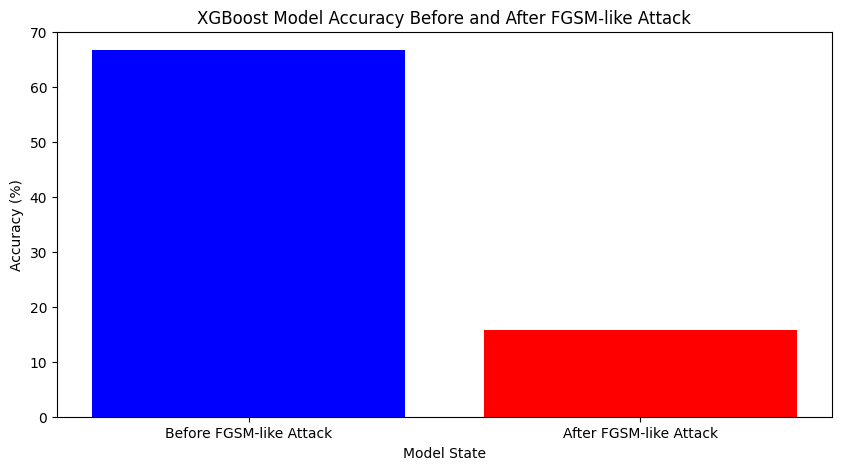

ValueError: multilabel-indicator is not supported

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.svm import SVC
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to plot decision boundaries
def plot_decision_boundary(X, y, model, title, pca, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Function to train and attack ANN model
def train_and_attack_ann(X_train, X_test, y_train, y_test, class_labels):
    # Define the Keras model
    model = Sequential()
    model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

    # Compile the Keras model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Fit the Keras model on the dataset
    model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

    # Evaluate the model on the test set before attack
    loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Wrap the model with ART's classifier
    classifier = TensorFlowV2Classifier(
        model=model,
        nb_classes=y_train.shape[1],
        input_shape=(X_train.shape[1],),
        loss_object=tf.keras.losses.CategoricalCrossentropy(),
        clip_values=(np.min(X_train), np.max(X_train))
    )

    # Initialize FGSM attack
    attack = FastGradientMethod(estimator=classifier, eps=0.1)

    # Perform FGSM attack on the test set
    X_test_adv = attack.generate(X_test)

    # Evaluate the model on the adversarial test set after attack
    loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM Attack', 'After FGSM Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('ANN Model Accuracy Before and After FGSM Attack')
    plt.show()

    # Confusion matrix before attack
    y_pred_before = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm_before = confusion_matrix(y_true, y_pred_before)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM Attack')
    plt.show()

    # Confusion matrix after attack
    y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

    cm_after = confusion_matrix(y_true, y_pred_after)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before FGSM Attack', pca, class_labels)
    plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After FGSM Attack', pca, class_labels)

# Function to train and attack CNN model
def train_and_attack_cnn(X_train, X_test, y_train, y_test, class_labels):
    # Define the CNN model
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

    # Compile the CNN model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Fit the CNN model on the dataset
    model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

    # Evaluate the model on the test set before attack
    loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Wrap the model with ART's classifier
    classifier = TensorFlowV2Classifier(
        model=model,
        nb_classes=y_train.shape[1],
        input_shape=(8, 8, 1),
        loss_object=tf.keras.losses.CategoricalCrossentropy(),
        clip_values=(np.min(X_train), np.max(X_train))
    )

    # Initialize FGSM attack
    attack = FastGradientMethod(estimator=classifier, eps=0.1)

    # Perform FGSM attack on the test set
    X_test_adv = attack.generate(X_test)

    # Evaluate the model on the adversarial test set after attack
    loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM Attack', 'After FGSM Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('CNN Model Accuracy Before and After FGSM Attack')
    plt.show()

    # Confusion matrix before attack
    y_pred_before = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm_before = confusion_matrix(y_true, y_pred_before)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM Attack')
    plt.show()

    # Confusion matrix after attack
    y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

    cm_after = confusion_matrix(y_true, y_pred_after)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM Attack')
    plt.show()

    # Visualize original vs adversarial values
    num_samples = 5  # Number of samples to visualize
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
        plt.title('Original')
        plt.axis('off')

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
        plt.title('Adversarial')
        plt.axis('off')
    plt.show()

# Function to train and attack XGBoost model
def train_and_attack_xgboost(X_train, X_test, y_train, y_test, class_labels):
    # Define and train the XGBoost model
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    xgb_model.fit(X_train, y_train)

    # Initial predictions and accuracy
    y_pred = xgb_model.predict(X_test)
    accuracy_before_attack = accuracy_score(y_test, y_pred)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Initialize FGSM-like perturbation
    eps = 0.1  # Perturbation magnitude

    # Apply FGSM-like perturbation
    perturbation = eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

    # Evaluate the model on the adversarial test set after attack
    y_pred_adv = xgb_model.predict(X_test_adv)
    accuracy_after_attack = accuracy_score(y_test, y_pred_adv)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM-like attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('XGBoost Model Accuracy Before and After FGSM-like Attack')
    plt.show()

    # Confusion matrix before attack
    cm_before = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM-like Attack')
    plt.show()

    # Confusion matrix after attack
    cm_after = confusion_matrix(y_test, y_pred_adv)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM-like Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, xgb_model, 'Decision Boundary Before FGSM-like Attack', pca, class_labels)
    plot_decision_boundary(X_test_adv_pca, y_test, xgb_model, 'Decision Boundary After FGSM-like Attack', pca, class_labels)

# Function to train and attack SVM model
def train_and_attack_svm(X_train, X_test, y_train, y_test, class_labels):
    # Define and train the SVM model
    svm_model = SVC(kernel='linear', probability=True)
    svm_model.fit(X_train, y_train)

    # Initial predictions and accuracy
    y_pred = svm_model.predict(X_test)
    accuracy_before_attack = accuracy_score(y_test, y_pred)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Initialize FGSM-like perturbation
    eps = 0.1  # Perturbation magnitude

    # Apply FGSM-like perturbation
    perturbation = eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

    # Evaluate the model on the adversarial test set after attack
    y_pred_adv = svm_model.predict(X_test_adv)
    accuracy_after_attack = accuracy_score(y_test, y_pred_adv)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM-like attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('SVM Model Accuracy Before and After FGSM-like Attack')
    plt.show()

    # Confusion matrix before attack
    cm_before = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM-like Attack')
    plt.show()

    # Confusion matrix after attack
    cm_after = confusion_matrix(y_test, y_pred_adv)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM-like Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, svm_model, 'Decision Boundary Before FGSM-like Attack', pca, class_labels)
    plot_decision_boundary(X_test_adv_pca, y_test, svm_model, 'Decision Boundary After FGSM-like Attack', pca, class_labels)

# Example usage of the functions for ANN
train_and_attack_ann(X_train, X_test, y_train, y_test, class_labels)

# Example usage of the functions for CNN
# Reshape data for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], 8, 8, 1)  # Adjust the shape according to your data
X_test_cnn = X_test.reshape(X_test.shape[0], 8, 8, 1)
train_and_attack_cnn(X_train_cnn, X_test_cnn, y_train, y_test, class_labels)

# Example usage of the functions for XGBoost
train_and_attack_xgboost(X_train, X_test, y_train, y_test, class_labels)

# Example usage of the functions for SVM
train_and_attack_svm(X_train, X_test, y_train, y_test, class_labels)


2024-07-26 21:04:23.881906: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-26 21:04:24.045442: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-26 21:04:24.045479: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-07-26 21:04:24.083688: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-26 21:04:25.013081: W tensorflow/stream_executor/pla

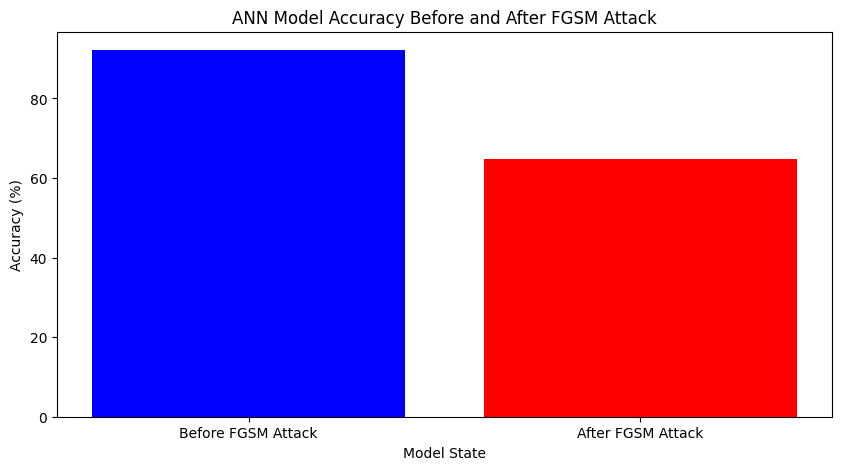

2/2 [==============================] - 0s 3ms/step


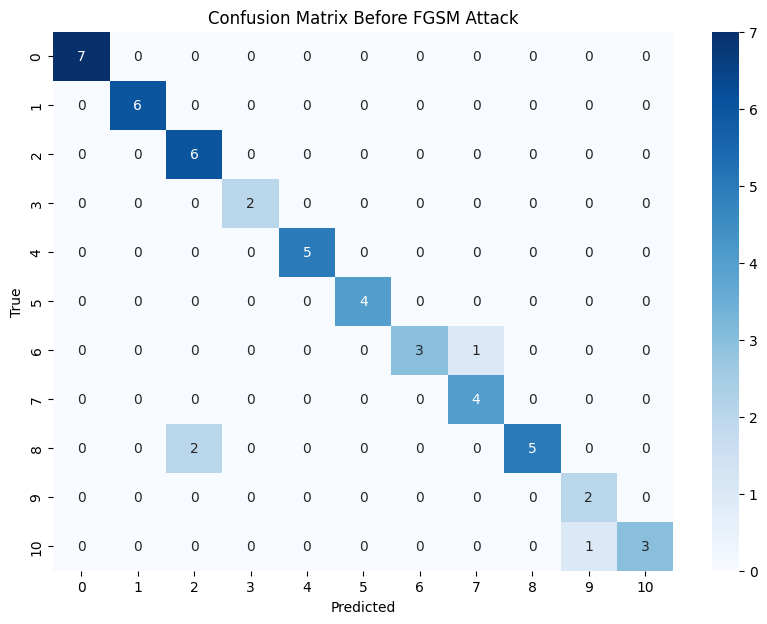

2/2 [==============================] - 0s 4ms/step


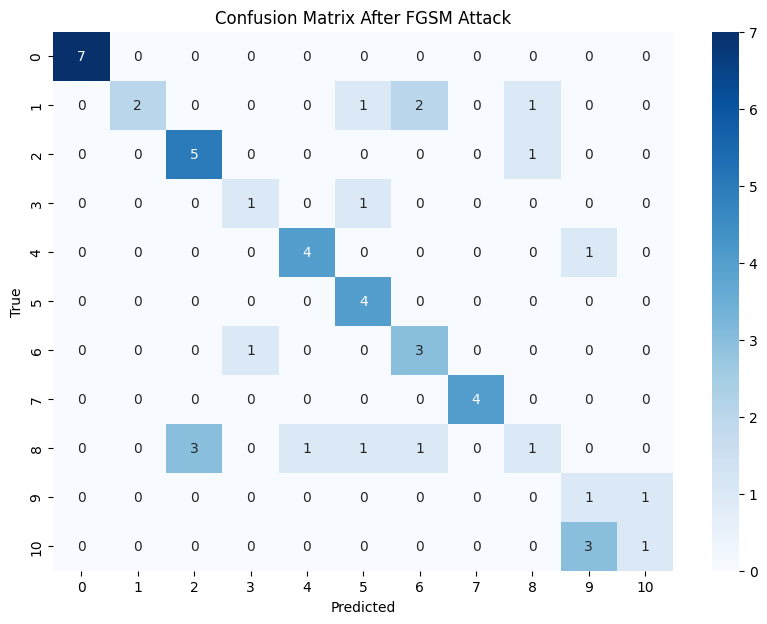

13723/13723 [==============================] - 18s 1ms/step


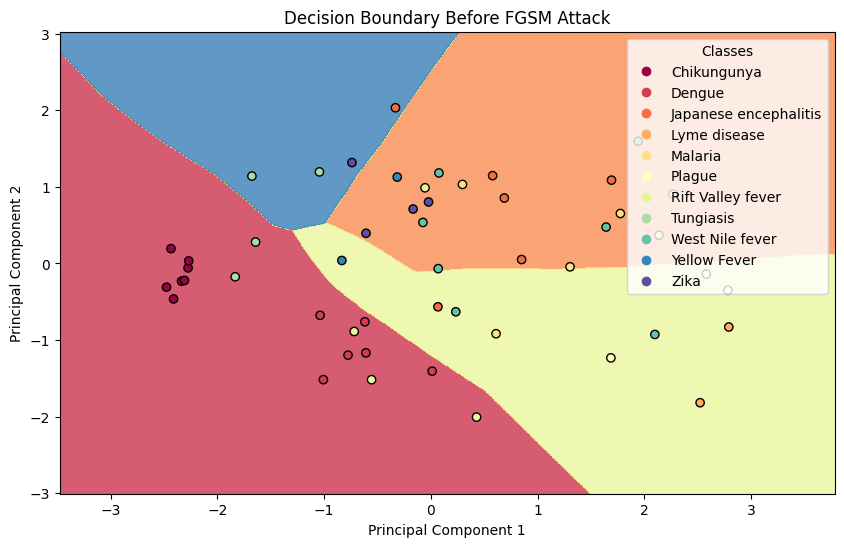

11633/11633 [==============================] - 14s 1ms/step


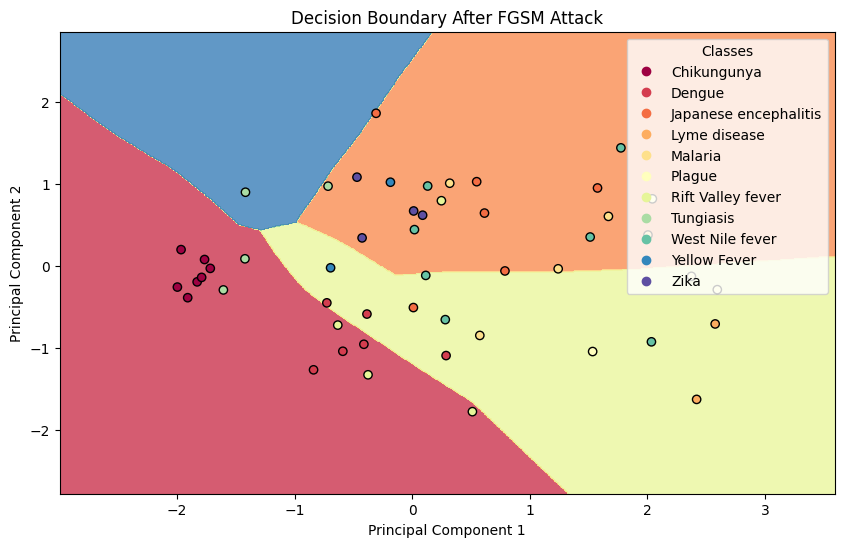

Epoch 1/10
21/21 [==============================] - 0s 2ms/step - loss: 2.3651 - accuracy: 0.1294
Epoch 2/10
21/21 [==============================] - 0s 4ms/step - loss: 2.1433 - accuracy: 0.4080
Epoch 3/10
21/21 [==============================] - 0s 2ms/step - loss: 1.8976 - accuracy: 0.4577
Epoch 4/10
21/21 [==============================] - 0s 4ms/step - loss: 1.5802 - accuracy: 0.6617
Epoch 5/10
21/21 [==============================] - 0s 4ms/step - loss: 1.2801 - accuracy: 0.6866
Epoch 6/10
21/21 [==============================] - 0s 2ms/step - loss: 0.9551 - accuracy: 0.8607
Epoch 7/10
21/21 [==============================] - 0s 3ms/step - loss: 0.7632 - accuracy: 0.8507
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.5912 - accuracy: 0.9055
Epoch 9/10
21/21 [==============================] - 0s 2ms/step - loss: 0.5642 - accuracy: 0.8358
Epoch 10/10
21/21 [==============================] - 0s 3ms/step - loss: 0.5198 - accuracy: 0.8458
Accuracy before att

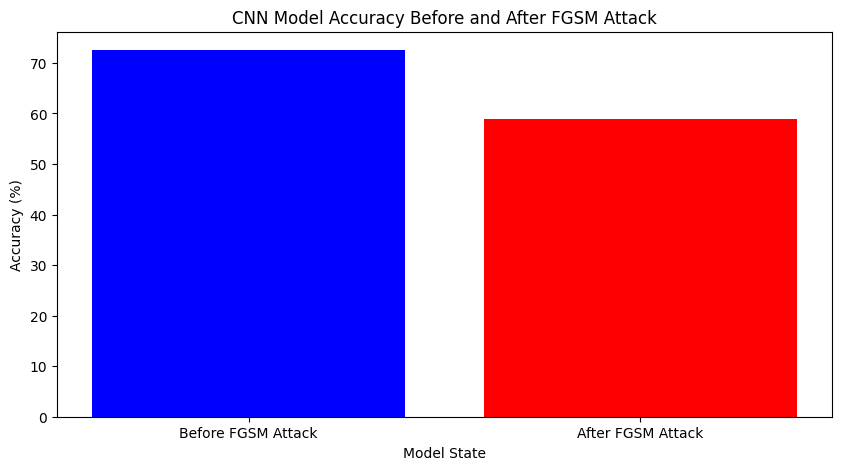

2/2 [==============================] - 0s 2ms/step


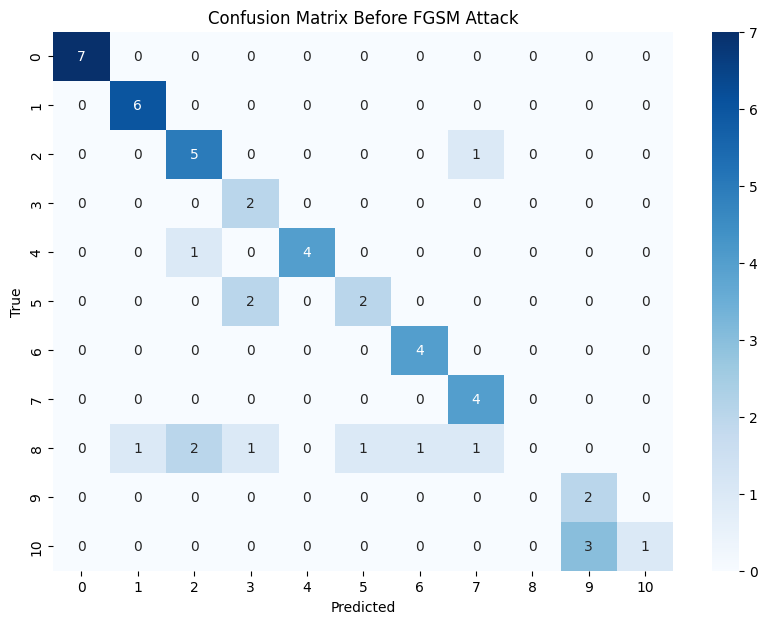

2/2 [==============================] - 0s 3ms/step


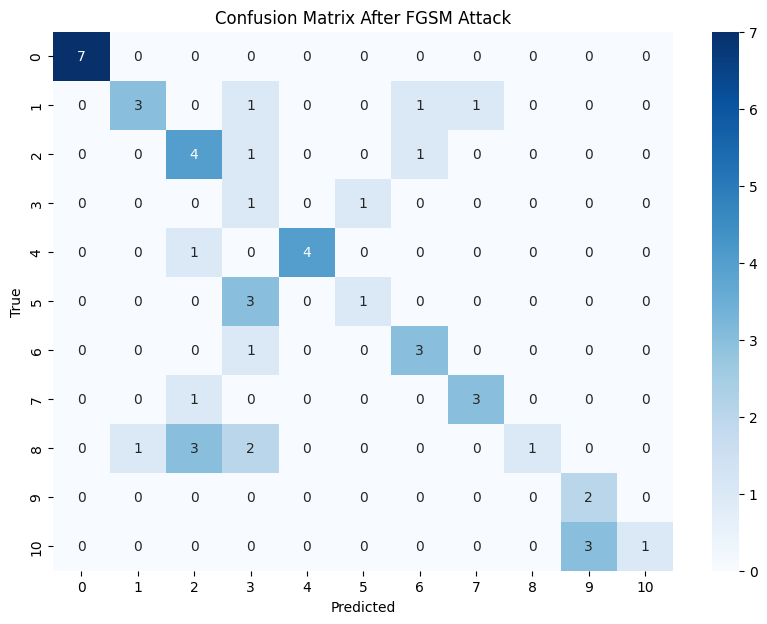

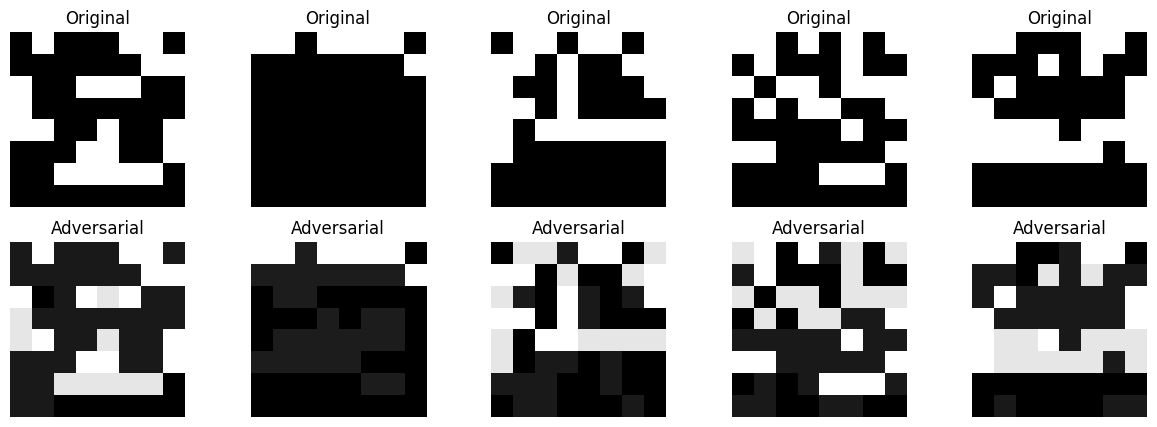

Accuracy before attack: 88.24%
Accuracy after attack: 39.22%


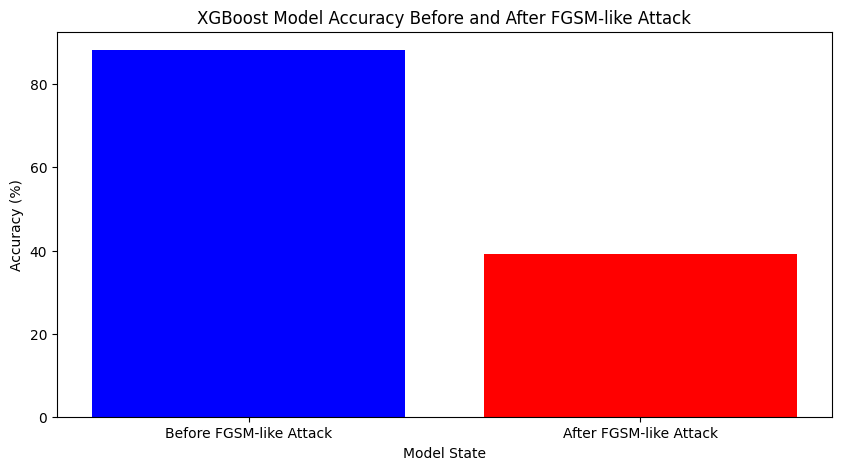

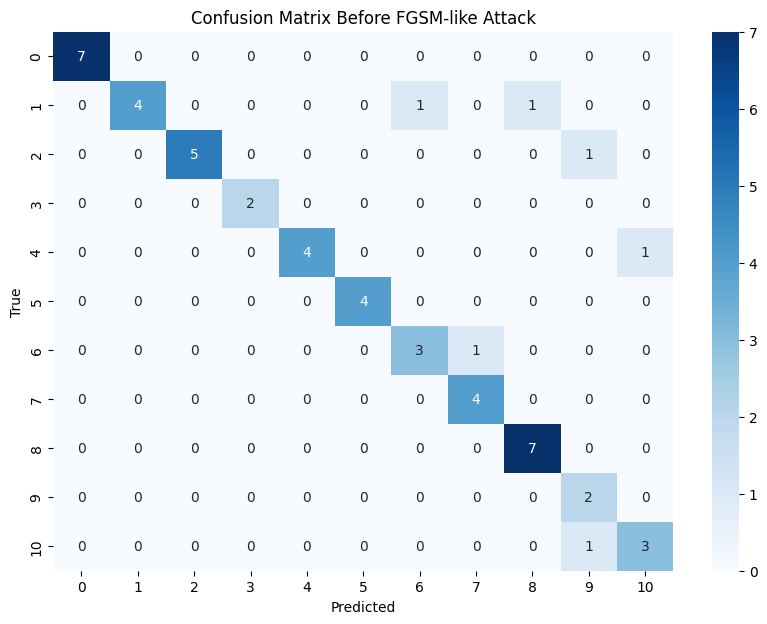

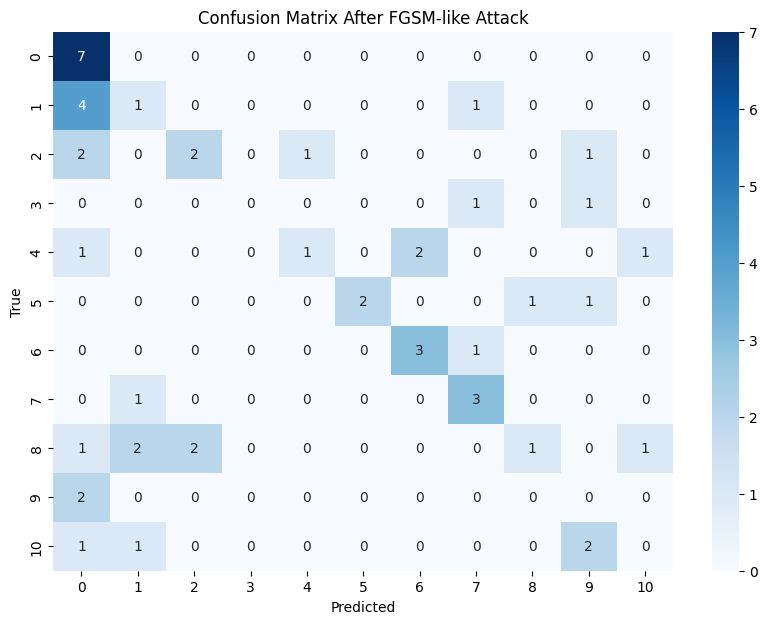

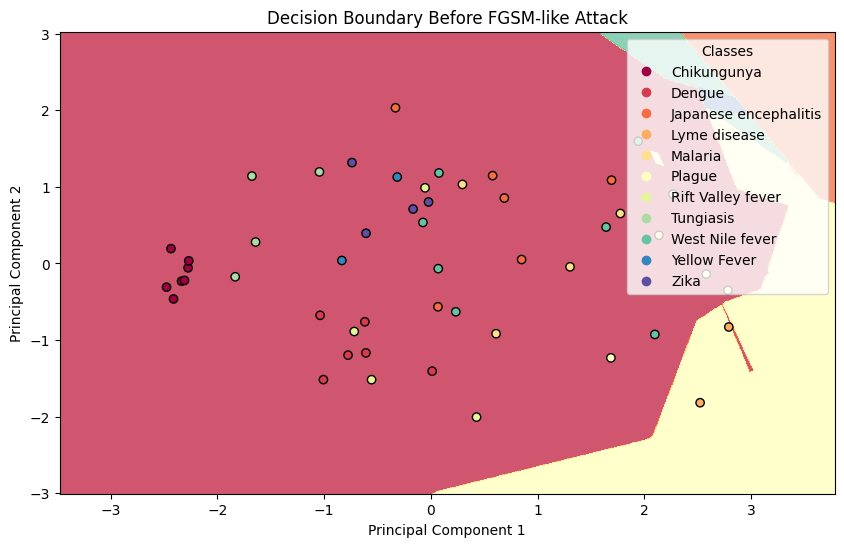

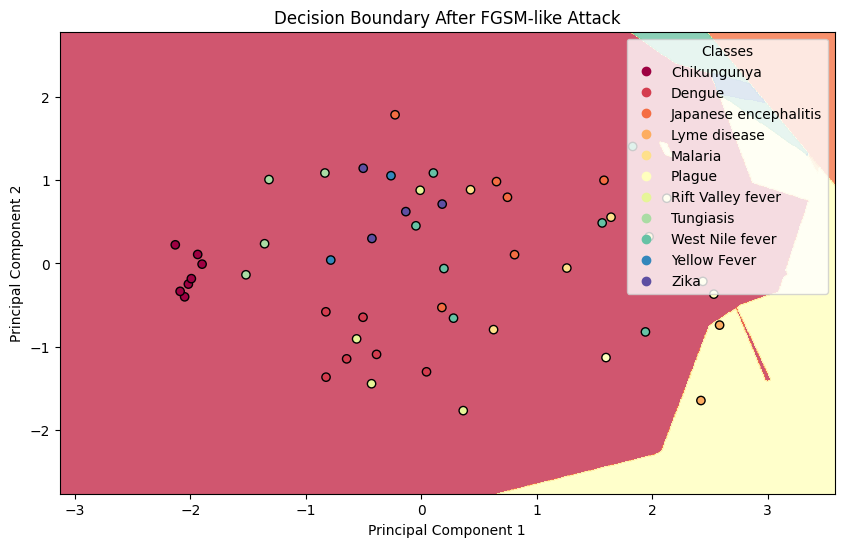

Accuracy before attack: 80.39%
Accuracy after attack: 84.31%


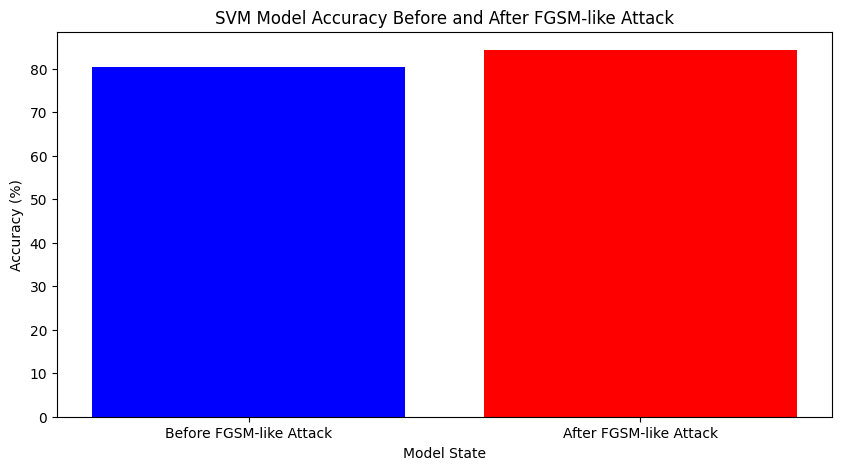

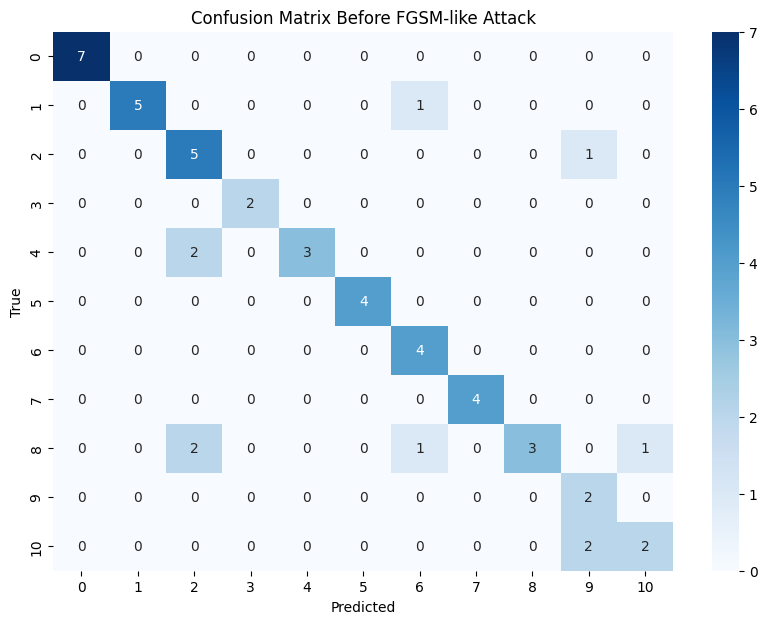

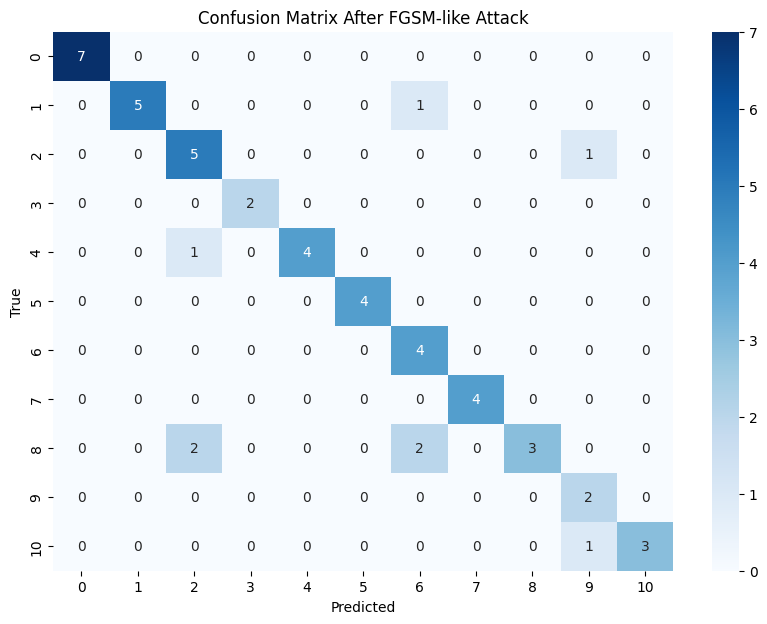

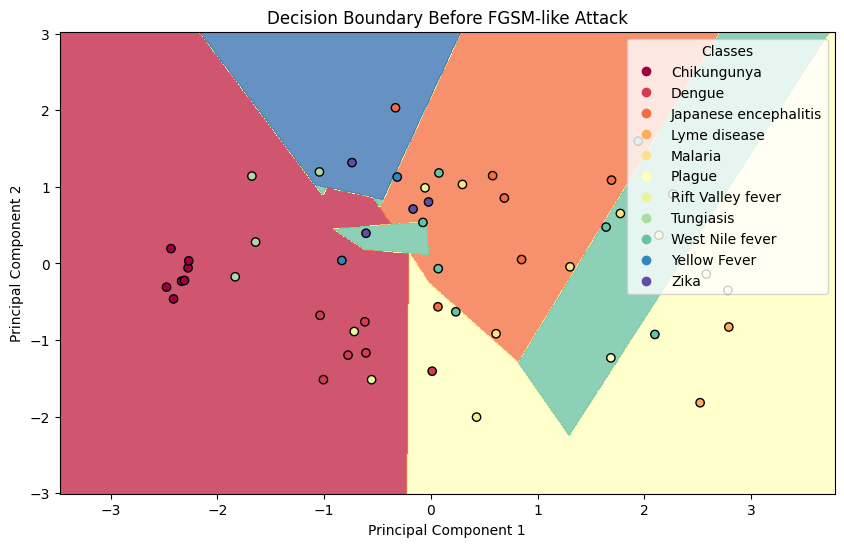

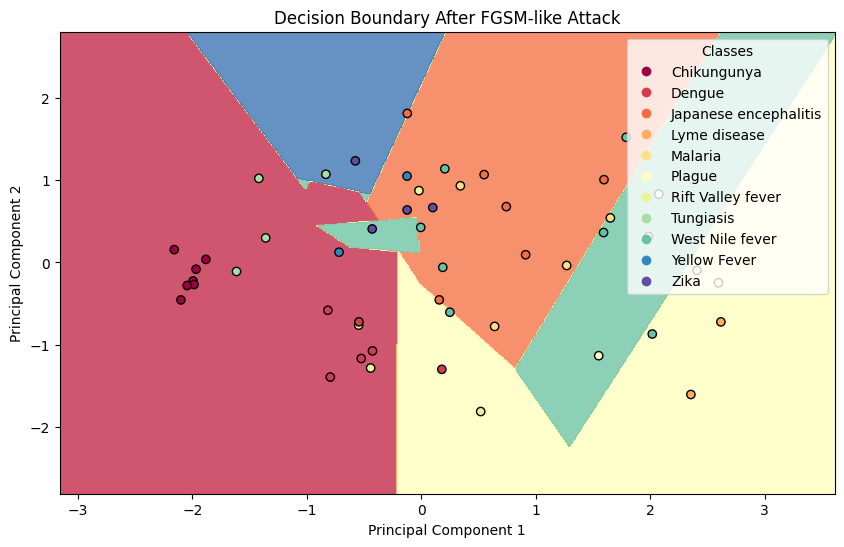

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.svm import SVC
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to plot decision boundaries
def plot_decision_boundary(X, y, model, title, pca, class_labels, is_keras_model=False):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    if is_keras_model:
        Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    else:
        Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
        
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Function to train and attack ANN model
def train_and_attack_ann(X_train, X_test, y_train, y_test, class_labels):
    # Define the Keras model
    model = Sequential()
    model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

    # Compile the Keras model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Fit the Keras model on the dataset
    model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

    # Evaluate the model on the test set before attack
    loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Wrap the model with ART's classifier
    classifier = TensorFlowV2Classifier(
        model=model,
        nb_classes=y_train.shape[1],
        input_shape=(X_train.shape[1],),
        loss_object=tf.keras.losses.CategoricalCrossentropy(),
        clip_values=(np.min(X_train), np.max(X_train))
    )

    # Initialize FGSM attack
    attack = FastGradientMethod(estimator=classifier, eps=0.1)

    # Perform FGSM attack on the test set
    X_test_adv = attack.generate(X_test)

    # Evaluate the model on the adversarial test set after attack
    loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM Attack', 'After FGSM Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('ANN Model Accuracy Before and After FGSM Attack')
    plt.show()

    # Confusion matrix before attack
    y_pred_before = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm_before = confusion_matrix(y_true, y_pred_before)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM Attack')
    plt.show()

    # Confusion matrix after attack
    y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

    cm_after = confusion_matrix(y_true, y_pred_after)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before FGSM Attack', pca, class_labels, is_keras_model=True)
    plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After FGSM Attack', pca, class_labels, is_keras_model=True)

# Function to train and attack CNN model
def train_and_attack_cnn(X_train, X_test, y_train, y_test, class_labels):
    # Define the CNN model
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

    # Compile the CNN model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Fit the CNN model on the dataset
    model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

    # Evaluate the model on the test set before attack
    loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Wrap the model with ART's classifier
    classifier = TensorFlowV2Classifier(
        model=model,
        nb_classes=y_train.shape[1],
        input_shape=(8, 8, 1),
        loss_object=tf.keras.losses.CategoricalCrossentropy(),
        clip_values=(np.min(X_train), np.max(X_train))
    )

    # Initialize FGSM attack
    attack = FastGradientMethod(estimator=classifier, eps=0.1)

    # Perform FGSM attack on the test set
    X_test_adv = attack.generate(X_test)

    # Evaluate the model on the adversarial test set after attack
    loss, accuracy_after_attack = model.evaluate(X_test_adv, y_test, verbose=0)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM Attack', 'After FGSM Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('CNN Model Accuracy Before and After FGSM Attack')
    plt.show()

    # Confusion matrix before attack
    y_pred_before = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm_before = confusion_matrix(y_true, y_pred_before)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM Attack')
    plt.show()

    # Confusion matrix after attack
    y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

    cm_after = confusion_matrix(y_true, y_pred_after)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM Attack')
    plt.show()

    # Visualize original vs adversarial values
    num_samples = 5  # Number of samples to visualize
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
        plt.title('Original')
        plt.axis('off')

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
        plt.title('Adversarial')
        plt.axis('off')
    plt.show()

# Function to train and attack XGBoost model
def train_and_attack_xgboost(X_train, X_test, y_train, y_test, class_labels):
    # Define and train the XGBoost model
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    xgb_model.fit(X_train, np.argmax(y_train, axis=1))

    # Initial predictions and accuracy
    y_pred = xgb_model.predict(X_test)
    accuracy_before_attack = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Initialize FGSM-like perturbation
    eps = 0.1  # Perturbation magnitude

    # Apply FGSM-like perturbation
    perturbation = eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

    # Evaluate the model on the adversarial test set after attack
    y_pred_adv = xgb_model.predict(X_test_adv)
    accuracy_after_attack = accuracy_score(np.argmax(y_test, axis=1), y_pred_adv)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM-like attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('XGBoost Model Accuracy Before and After FGSM-like Attack')
    plt.show()

    # Confusion matrix before attack
    cm_before = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM-like Attack')
    plt.show()

    # Confusion matrix after attack
    cm_after = confusion_matrix(np.argmax(y_test, axis=1), y_pred_adv)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM-like Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, xgb_model, 'Decision Boundary Before FGSM-like Attack', pca, class_labels)
    plot_decision_boundary(X_test_adv_pca, y_test, xgb_model, 'Decision Boundary After FGSM-like Attack', pca, class_labels)

# Function to train and attack SVM model
def train_and_attack_svm(X_train, X_test, y_train, y_test, class_labels):
    # Define and train the SVM model
    svm_model = SVC(kernel='linear', probability=True)
    svm_model.fit(X_train, np.argmax(y_train, axis=1))

    # Initial predictions and accuracy
    y_pred = svm_model.predict(X_test)
    accuracy_before_attack = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

    # Initialize FGSM-like perturbation
    eps = 0.1  # Perturbation magnitude

    # Apply FGSM-like perturbation
    perturbation = eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv = np.clip(X_test + perturbation, 0, 1)  # Ensure values are within valid range

    # Evaluate the model on the adversarial test set after attack
    y_pred_adv = svm_model.predict(X_test_adv)
    accuracy_after_attack = accuracy_score(np.argmax(y_test, axis=1), y_pred_adv)
    print(f"Accuracy after attack: {accuracy_after_attack*100:.2f}%")

    # Plot model accuracy before and after FGSM-like attack
    accuracies = [accuracy_before_attack * 100, accuracy_after_attack * 100]
    labels = ['Before FGSM-like Attack', 'After FGSM-like Attack']

    plt.figure(figsize=(10, 5))
    plt.bar(labels, accuracies, color=['blue', 'red'])
    plt.xlabel('Model State')
    plt.ylabel('Accuracy (%)')
    plt.title('SVM Model Accuracy Before and After FGSM-like Attack')
    plt.show()

    # Confusion matrix before attack
    cm_before = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix Before FGSM-like Attack')
    plt.show()

    # Confusion matrix after attack
    cm_after = confusion_matrix(np.argmax(y_test, axis=1), y_pred_adv)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix After FGSM-like Attack')
    plt.show()

    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_test_pca = pca.fit_transform(X_test)
    X_test_adv_pca = pca.transform(X_test_adv)

    # Plot decision boundaries
    plot_decision_boundary(X_test_pca, y_test, svm_model, 'Decision Boundary Before FGSM-like Attack', pca, class_labels)
    plot_decision_boundary(X_test_adv_pca, y_test, svm_model, 'Decision Boundary After FGSM-like Attack', pca, class_labels)

# Example usage of the functions for ANN
train_and_attack_ann(X_train, X_test, y_train, y_test, class_labels)

# Example usage of the functions for CNN
# Reshape data for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], 8, 8, 1)  # Adjust the shape according to your data
X_test_cnn = X_test.reshape(X_test.shape[0], 8, 8, 1)
train_and_attack_cnn(X_train_cnn, X_test_cnn, y_train, y_test, class_labels)

# Example usage of the functions for XGBoost
train_and_attack_xgboost(X_train, X_test, y_train, y_test, class_labels)

# Example usage of the functions for SVM
train_and_attack_svm(X_train, X_test, y_train, y_test, class_labels)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82fc1969-7ff0-4344-a3e7-65ed95a291e5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>